##Predicting Stellar Parallax Using GPU-Accelerated Machine Learning

**Student:** Atheer

**Datasets:** [ESA Gaia DR3](https://astroquery.readthedocs.io/en/latest/gaia/gaia.html).

The European Space Agency's Gaia mission provides measurements of the positions, brightness, colour, and parallax of more than 1.8 billion sources. Gaia DR3 contains about 1.81 billion sources in total.


This project uses GPU-accelerated machine learning with RAPIDS cuDF and cuML to predict a star's parallax using observable properties such as brightness, colour, and sky position.


### Research Questions

1. Can machine learning predict a star's Gaia-measured parallax using only observable properties such as brightness, colour, and sky position?

2. Which observable features are most strongly associated with parallax?






## 1.GPU Setup

In [ ]:
!nvidia-smi  # display information about available nvidia GPUs

Wed Aug 12 14:18:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Download RAPIDS libraries
import cudf
import cuml
import cupy as cp

# Display RAPIDS libraries Versions
print("cuDF Version :", cudf.__version__)
print("cuML Version :", cuml.__version__)
print("CuPy Version :", cp.__version__)

cuDF Version : 26.02.01
cuML Version : 26.02.000
CuPy Version : 14.0.1


In [ ]:
# Display GPU information لمعرفة عدد GPU
print("Number of GPUs :", cp.cuda.runtime.getDeviceCount())
device = cp.cuda.Device(0)
print("Current GPU ID :", device.id)

Number of GPUs : 1
Current GPU ID : 0


### 1.1 GPU performance monitoring


In [ ]:
# get GPU utilization and memory usage
import subprocess

def get_gpu_stats():
    """Return (utilization %, memory used in MB) using a single nvidia-smi reading."""
    output = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=utilization.gpu,memory.used", "--format=csv,noheader,nounits"]
    ).decode().strip()
    util_str, mem_str = output.split(",")
    return int(util_str), int(mem_str)

# Quick check that it works or not
print("Current GPU Utilization / Memory:", get_gpu_stats())

Current GPU Utilization / Memory: (0, 3)


## 2.Download the Libraries

In [ ]:
# Download the library for Data Manipulation and Visualization
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Download the Modelling
from cuml.preprocessing import StandardScaler
from cuml.model_selection import train_test_split
from cuml.linear_model import LinearRegression
from cuml.ensemble import RandomForestRegressor
import xgboost as xgb
from cuml.cluster import KMeans


# Download the Evaluation
from cuml.metrics import mean_absolute_error, mean_squared_error, r2_score

## 3.Download the Gaia Datasets

Astroquery is used to access the Gaia Archive and retrieve the selected Gaia DR3 data using an ADQL query.

In [ ]:
# Install astroquery for accessing the Gaia Archive
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 114.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 76.2 MB/s eta 0:00:00


In [ ]:
from astroquery.gaia import Gaia

In [ ]:
query = """
SELECT TOP 2000000
    source_id,
    ra,
    dec,
    phot_g_mean_mag,
    bp_rp,
    parallax,
    parallax_over_error,
    parallax_error,
    ruwe
FROM gaiadr3.gaia_source
WHERE
    parallax IS NOT NULL
    AND phot_g_mean_mag IS NOT NULL
    AND bp_rp IS NOT NULL
ORDER BY random_index
"""


job = Gaia.launch_job_async(query)
gaia_raw = job.get_results().to_pandas() ## get_results() يعيد النتائج كجدول Astropy  ##ثم نحولها إلى Pandas. to save the datasets in csv


gaia_raw.head()

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_over_error,parallax_error,ruwe
0,4267180339403392768,286.716913,0.276195,15.244129,1.522128,1.084924,32.452808,0.033431,1.033783
1,5252403815119316480,152.625068,-64.267699,20.906347,0.702095,0.854356,0.666050,1.282721,0.912624
2,1937745177867542656,348.434982,43.940704,20.531225,1.649284,1.042008,1.645391,0.633289,1.051422
3,5971301282285218048,252.729717,-37.917215,20.145899,2.006773,0.587660,0.928237,0.633092,1.083541
4,5953201637243132416,260.678787,-44.788772,19.787357,1.573410,-0.293376,-0.473274,0.619885,1.251593


In [ ]:
# Save the downloaded dataset in csv file to avoid requerying the Gaia Archive when rerunning the notebook.
gaia_raw.to_csv("gaia_raw_2M.csv", index=False)

## 4.Load Dataset using cuDF

In [ ]:
# Load the downloaded Gaia dataset into GPU memory
gaia_gdf = cudf.read_csv("gaia_raw_2M.csv")
gaia_gdf.head()

,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_over_error,parallax_error,ruwe
0,4267180339403392768,286.716913,0.276195,15.244129,1.522128,1.084924,32.452810,0.033431,1.033783
1,5252403815119316480,152.625068,-64.267699,20.906347,0.702095,0.854356,0.666050,1.282721,0.912624
2,1937745177867542656,348.434982,43.940704,20.531225,1.649284,1.042008,1.645391,0.633289,1.051422
3,5971301282285218048,252.729717,-37.917215,20.145899,2.006773,0.587660,0.928237,0.633092,1.083541
4,5953201637243132416,260.678787,-44.788772,19.787357,1.573410,-0.293376,-0.473274,0.619885,1.251592


## 5. Data Understanding

In [ ]:
# show the number of rows and columns
print("Dataset Shape:", gaia_gdf.shape)
print("Columns:", gaia_gdf.columns.tolist())

Dataset Shape: (2000000, 9)
Columns: ['source_id', 'ra', 'dec', 'phot_g_mean_mag', 'bp_rp', 'parallax', 'parallax_over_error', 'parallax_error', 'ruwe']


| Feature               | What it means                                     |
| --------------------- | ------------------------------------------------- |
| `source_id`           | Unique ID for each star                           |
| `ra`                  | Horizontal sky position                           |
| `dec`                 | Vertical sky position                             |
| `phot_g_mean_mag`     | Star brightness                                   |
| `bp_rp`               | Star colour                                       |
| `parallax`            | Measurement related to star distance; **target**  |
| `parallax_error`      | Estimated uncertainty of the parallax measurement |
| `parallax_over_error` | Indicator of parallax measurement quality         |
| `ruwe`                | Indicator of astrometric measurement quality      |


In [ ]:
# show dataset information
gaia_gdf.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 9 columns):
 #   Column               Dtype
---  ------               -----
 0   source_id            int64
 1   ra                   float64
 2   dec                  float64
 3   phot_g_mean_mag      float64
 4   bp_rp                float64
 5   parallax             float64
 6   parallax_over_error  float64
 7   parallax_error       float64
 8   ruwe                 float64
dtypes: float64(8), int64(1)
memory usage: 137.3 MB


In [ ]:
# show data types
gaia_gdf.dtypes

,0
source_id,int64
ra,float64
dec,float64
phot_g_mean_mag,float64
bp_rp,float64
parallax,float64
parallax_over_error,float64
parallax_error,float64
ruwe,float64


In [ ]:
# Show summary of all columns in the dataset
gaia_gdf.describe(include="all")

,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_over_error,parallax_error,ruwe
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,4.307959e+18,2.242583e+02,-1.667751e+01,1.894531e+01,1.620167e+00,3.762456e-01,3.917848e+00,4.396013e-01,1.096415e+00
std,1.719242e+18,8.155251e+01,3.836929e+01,1.576876e+00,6.103124e-01,9.852445e-01,1.882202e+01,4.078241e-01,6.238617e-01
min,4.215940e+13,2.620729e-04,-8.992248e+01,3.023800e+00,-3.801178e+00,-5.227991e+01,-3.695412e+01,7.789557e-03,4.925589e-01
25%,3.342734e+18,1.699950e+02,-4.871329e+01,1.819884e+01,1.194176e+00,2.838367e-02,8.229523e-02,1.443287e-01,9.871709e-01
50%,4.313902e+18,2.561269e+02,-2.406575e+01,1.934599e+01,1.530914e+00,3.097361e-01,1.155851e+00,3.190262e-01,1.021753e+00
75%,5.860669e+18,2.821186e+02,1.209626e+01,2.011993e+01,1.955666e+00,6.673043e-01,2.780630e+00,6.047366e-01,1.065702e+00
max,6.917516e+18,3.599984e+02,8.977689e+01,2.128420e+01,7.758104e+00,7.556888e+01,5.014804e+03,4.889755e+00,6.291776e+01


The summary statistics show differences (variation) in stellar brightness, colour, parallax, and astrometric quality indicators.


In [ ]:
# Count the number of unique values in each columns
gaia_gdf.nunique()

source_id              2000000
ra                     2000000
dec                    2000000
phot_g_mean_mag        1344463
bp_rp                  1007037
parallax               2000000
parallax_over_error    1973708
parallax_error         1953544
ruwe                   1374888
dtype: int64

In [ ]:
# Check for the missing values
missing = gaia_gdf.isnull().sum()
missing_pct = ( gaia_gdf.isnull().sum() / len(gaia_gdf) * 100).round(2)
missing_table = cudf.DataFrame({ "Missing Count": missing, "Missing Percentage": missing_pct})
missing_table.sort_values( by="Missing Count", ascending=False)

,Missing Count,Missing Percentage
source_id,0,0.0
ra,0,0.0
dec,0,0.0
phot_g_mean_mag,0,0.0
bp_rp,0,0.0
parallax,0,0.0
parallax_over_error,0,0.0
parallax_error,0,0.0
ruwe,0,0.0


In [ ]:
# Check for duplicate rows in all the dataset
print("Duplicate rows:", gaia_gdf.duplicated().sum())

Duplicate rows: 0


In [ ]:
# Display memory usage
memory = gaia_gdf.memory_usage()
memory

Index                         0
source_id              16000000
ra                     16000000
dec                    16000000
phot_g_mean_mag        16000000
bp_rp                  16000000
parallax               16000000
parallax_over_error    16000000
parallax_error         16000000
ruwe                   16000000
dtype: int64

In [ ]:
# Total memory usage
total_memory = memory.sum() / (1024**2)
print(f"Total Memory Usage: {total_memory:.2f} MB")

Total Memory Usage: 137.33 MB


The dataset contains 2,000,000 Gaia observations and 9 numerical columns. No missing values or duplicate rows were found.

The source_id column uniquely identifies each Gaia source and is retained only as an identifier.
It is not used as a machine learning feature because it does not represent a physical property of the star.


## 6.Data Cleaning

In [ ]:
# Create a copy to use it in cleaning step to avoid change on the raw dataset
gaia_clean = gaia_gdf.copy()

In [ ]:
# Dataset shape before cleaning
print("Before Cleaning:", gaia_clean.shape)

Before Cleaning: (2000000, 9)


No missing values or duplicate rows were found during the Data Understanding.
The following steps are still applied to ensure the cleaned dataset contains no missing or duplicate records.

In [ ]:
# Remove duplicate rows
gaia_clean = gaia_clean.drop_duplicates()

In [ ]:
# Remove missing values
gaia_clean = gaia_clean.dropna()

####Astrometric Quality Filtering

RUWE (Renormalised Unit Weight Error) is an indicator of the quality of Gaia's astrometric solution.

Values close to 1 generally indicate a good fit, while higher values may indicate a poorer fit or possible issues with the source.

A threshold of RUWE < 1.4 is used to retain sources with higher-quality astrometric measurements.

RUWE is used only for data-quality filtering and is not included as a machine learning feature.

In [ ]:
# Count sources with low-quality astrometric solutions
ruwe_removed = (gaia_clean["ruwe"] >= 1.4).sum()
print("Records with RUWE >= 1.4:", ruwe_removed)

Records with RUWE >= 1.4: 84759


In [ ]:
# Keep only high-quality measurements
gaia_clean = gaia_clean[gaia_clean["ruwe"] < 1.4]
print("After RUWE filter:", gaia_clean.shape)

After RUWE filter: (1915241, 9)


In [ ]:
# Calculate the number of removed records
removed = len(gaia_gdf) - len(gaia_clean)
print("Removed Records:", removed)
print(f"Removal Percentage: {(removed / len(gaia_gdf)) * 100:.2f}%" )

Removed Records: 84759
Removal Percentage: 4.24%


The RUWE filter removed 84,759 sources (4.24%), leaving 1,915,241 sources for the analysis.

In [ ]:
# check the cleaned dataset to make sure there are no Missing and no Duplicate data
print("Missing Values After Cleaning:")
print(gaia_clean.isnull().sum())

print("\nDuplicate Rows After Cleaning:", gaia_clean.duplicated().sum())

Missing Values After Cleaning:
source_id              0
ra                     0
dec                    0
phot_g_mean_mag        0
bp_rp                  0
parallax               0
parallax_over_error    0
parallax_error         0
ruwe                   0
dtype: int64

Duplicate Rows After Cleaning: 0


In [ ]:
# show the max RUWE star number
print("Maximum RUWE After Cleaning:", gaia_clean["ruwe"].max())

Maximum RUWE After Cleaning: 1.3999925


In [ ]:
# Dataset shape after cleaning
print("Final cleaned dataset shape:", gaia_clean.shape)

Final cleaned dataset shape: (1915241, 9)


In [ ]:
gaia_clean.head()

,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_over_error,parallax_error,ruwe
0,4267180339403392768,286.716913,0.276195,15.244129,1.522128,1.084924,32.452810,0.033431,1.033783
1,5252403815119316480,152.625068,-64.267699,20.906347,0.702095,0.854356,0.666050,1.282721,0.912624
2,1937745177867542656,348.434982,43.940704,20.531225,1.649284,1.042008,1.645391,0.633289,1.051422
3,5971301282285218048,252.729717,-37.917215,20.145899,2.006773,0.587660,0.928237,0.633092,1.083541
4,5953201637243132416,260.678787,-44.788772,19.787357,1.573410,-0.293376,-0.473274,0.619885,1.251592


####Negative Parallax Values

Some parallax values can be negative because the measured value is affected by uncertainty in the observation.

These values are kept in the machine learning dataset because they are recorded parallax measurements. Removing them only because they are negative could affect the distribution of the dataset.

They are excluded only from distance calculations in the EDA section because distance cannot be calculated using zero or negative parallax.

In [ ]:
# Count negative parallax values
negative_parallax = (gaia_clean["parallax"] < 0).sum()
print("Negative parallax values:", negative_parallax)

Negative parallax values: 435963


##7.Feature Engineering

####Angular Coordinate Transformation

Right Ascension (RA) and Declination (Dec) describe the position of a star in the sky.

Because (RA) is an angular value, it has a wraparound problem. For example,(RA) = 359° and (RA)= 1° represent nearby positions, although their numerical values are far apart.
To represent these positions more continuously, sine and cosine transformations are applied to (RA) and (Dec).

The transformations use only (RA) and (Dec) and do not use the target variable (parallax). Therefore, they do not introduce data leakage.

In [ ]:
# Angular Feature Engineering
gaia_clean["ra_sin"] = cp.sin(cp.deg2rad(gaia_clean["ra"]))
gaia_clean["ra_cos"] = cp.cos(cp.deg2rad(gaia_clean["ra"]))

gaia_clean["dec_sin"] = cp.sin(cp.deg2rad(gaia_clean["dec"]))
gaia_clean["dec_cos"] = cp.cos(cp.deg2rad(gaia_clean["dec"]))

Brightness (phot_g_mean_mag) and colour (bp_rp) describe different properties of each star. To give the models more information about possible relationships between these variables and (parallax), squared and interaction features are created.

The squared features are:
`phot_g_mean_mag_sq = phot_g_mean_mag² ` , `bp_rp_sq = bp_rp²`

They allow the models to capture possible nonlinear relationships instead of only simple linear relationships.

The interaction feature is: `mag_color_interaction = phot_g_mean_mag × bp_rp `

It combines brightness and colour to allow the models to consider their combined effect.

These features use only the original input variables and do not use the target variable (parallax). Therefore, they do not introduce data leakage.

In [ ]:
# Feature Engineering from brightness and colour

# Squared brightness
gaia_clean["phot_g_mean_mag_sq"] = (gaia_clean["phot_g_mean_mag"] ** 2)

# Squared colour
gaia_clean["bp_rp_sq"] = (gaia_clean["bp_rp"] ** 2)

In [ ]:
# Interaction between brightness and colour
gaia_clean["mag_color_interaction"] = (gaia_clean["phot_g_mean_mag"] * gaia_clean["bp_rp"])

In [ ]:
gaia_clean.head()

,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_over_error,parallax_error,ruwe,ra_sin,ra_cos,dec_sin,dec_cos,phot_g_mean_mag_sq,bp_rp_sq,mag_color_interaction
0,4267180339403392768,286.716913,0.276195,15.244129,1.522128,1.084924,32.452810,0.033431,1.033783,-0.957738,0.287643,0.004820,0.999988,232.383469,2.316874,23.203517
1,5252403815119316480,152.625068,-64.267699,20.906347,0.702095,0.854356,0.666050,1.282721,0.912624,0.459811,-0.888017,-0.900832,0.434167,437.075345,0.492937,14.678242
2,1937745177867542656,348.434982,43.940704,20.531225,1.649284,1.042008,1.645391,0.633289,1.051422,-0.200480,0.979698,0.693914,0.720058,421.531200,2.720139,33.861829
3,5971301282285218048,252.729717,-37.917215,20.145899,2.006773,0.587660,0.928237,0.633092,1.083541,-0.954915,-0.296880,-0.614522,0.788899,405.857247,4.027138,40.428246
4,5953201637243132416,260.678787,-44.788772,19.787357,1.573410,-0.293376,-0.473274,0.619885,1.251592,-0.986796,-0.161969,-0.704495,0.709709,391.539497,2.475619,31.133625


In [ ]:
print("Dataset Shape:", gaia_clean.shape)
print("Columns:", gaia_clean.columns.tolist())

Dataset Shape: (1915241, 16)
Columns: ['source_id', 'ra', 'dec', 'phot_g_mean_mag', 'bp_rp', 'parallax', 'parallax_over_error', 'parallax_error', 'ruwe', 'ra_sin', 'ra_cos', 'dec_sin', 'dec_cos', 'phot_g_mean_mag_sq', 'bp_rp_sq', 'mag_color_interaction']


In [ ]:
# Save the dataset after the cleaning and feature engineering to use it in EDA and training the models to avoid change on raw dataset
gaia_clean.to_csv("gaia_clean_2M.csv", index=False)

####Distance and Absolute Magnitude features — EDA Only

Stellar distance and absolute magnitude are calculated using parallax and are useful for astronomical analysis and visualization.

`distance_pc = 1000 / parallax`

`absolute_magnitude = phot_g_mean_mag - 5 * log10(distance_pc) + 5`

Since parallax is the target variable, using them as an input features would introduce target leakage.
In this project, these values are not used as machine learning features.
Therefore, they are calculated later only in the EDA section on a separate copy of the data.



####parallax_over_error feature — EDA Only

parallax_over_error is calculated from parallax and its measurement error.

`parallax_over_error = parallax / parallax_error `

Because it directly uses the target variable(parallax), it is not used as a machine learning input feature. It is used only as a data-quality indicator during EDA.

## 8.Exploratory Data Analysis (EDA)

The cleaned cuDF dataset is converted to Pandas only for the EDA, because Matplotlib and Seaborn require CPU-based data for visualization. All data cleaning, feature engineering, and model training remain on the GPU.

In [ ]:
# Convert the cleaned GPU DataFrame to Pandas for visualization
eda_df = gaia_clean.to_pandas()
print("EDA Dataset Shape:", eda_df.shape)

EDA Dataset Shape: (1915241, 16)


In [ ]:
# Keep only positive parallaxes for distance-based EDA, since distance cannot be calculated from zero or negative parallax.
eda_df_positive = eda_df[eda_df["parallax"] > 0].copy()
print("Positive Parallax EDA Shape:", eda_df_positive.shape)

Positive Parallax EDA Shape: (1479278, 16)


In [ ]:
# Calculate the distance to each star in parsecs (pc), which is a common unit used to measure distances between stars.
eda_df_positive["distance_pc"] = 1000 / eda_df_positive["parallax"]

# Calculate the absolute G-band magnitude, which represents the star's intrinsic brightness independent of distance.
eda_df_positive["absolute_magnitude"] = (eda_df_positive["phot_g_mean_mag"] - 5 * np.log10(eda_df_positive["distance_pc"]) + 5 )

print("EDA Dataset with Derived Variables:", eda_df_positive.shape)

EDA Dataset with Derived Variables: (1479278, 18)


In [ ]:
eda_df_positive.head()

,source_id,ra,dec,phot_g_mean_mag,bp_rp,parallax,parallax_over_error,parallax_error,ruwe,ra_sin,ra_cos,dec_sin,dec_cos,phot_g_mean_mag_sq,bp_rp_sq,mag_color_interaction,distance_pc,absolute_magnitude
0,4267180339403392768,286.716913,0.276195,15.244129,1.522128,1.084924,32.452810,0.033431,1.033783,-0.957738,0.287643,0.004820,0.999988,232.383469,2.316874,23.203517,921.723669,5.421125
1,5252403815119316480,152.625068,-64.267699,20.906347,0.702095,0.854356,0.666050,1.282721,0.912624,0.459811,-0.888017,-0.900832,0.434167,437.075345,0.492937,14.678242,1170.471687,10.564542
2,1937745177867542656,348.434982,43.940704,20.531225,1.649284,1.042008,1.645391,0.633289,1.051422,-0.200480,0.979698,0.693914,0.720058,421.531200,2.720139,33.861829,959.685861,10.620580
3,5971301282285218048,252.729717,-37.917215,20.145899,2.006773,0.587660,0.928237,0.633092,1.083541,-0.954915,-0.296880,-0.614522,0.788899,405.857247,4.027138,40.428246,1701.664713,8.991529
5,6125916630291830144,186.180736,-50.756590,19.050842,1.396774,0.436940,2.021490,0.216148,1.037380,-0.107665,-0.994187,-0.774465,0.632616,362.934581,1.950978,26.609726,2288.641734,7.252953


###8.1 ML Feature EDA

In [ ]:
ml_feature_cols = [
    "phot_g_mean_mag",
    "bp_rp",
    "ra_sin",
    "ra_cos",
    "dec_sin",
    "dec_cos",
    "phot_g_mean_mag_sq",
    "bp_rp_sq",
    "mag_color_interaction"
]

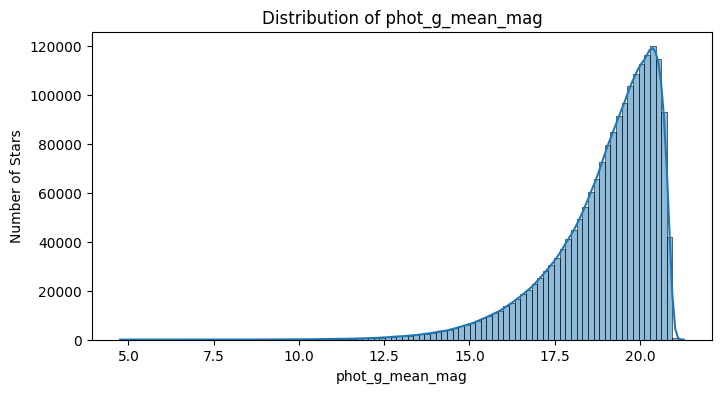

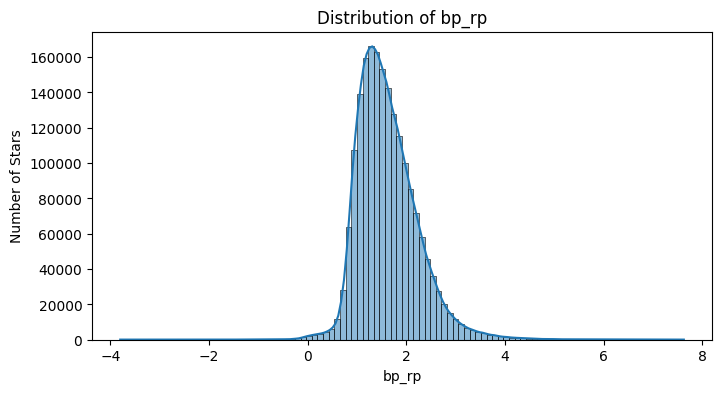

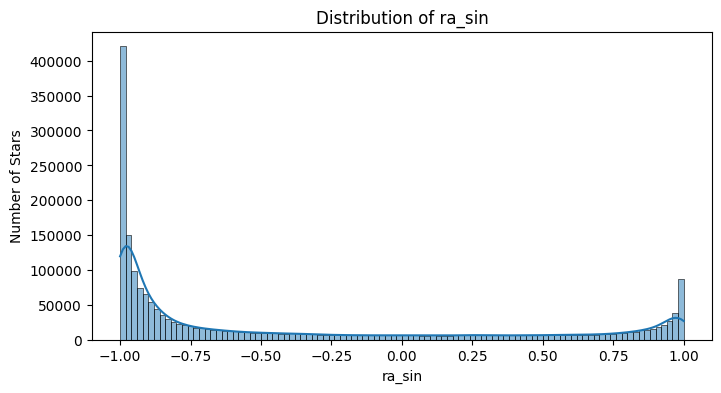

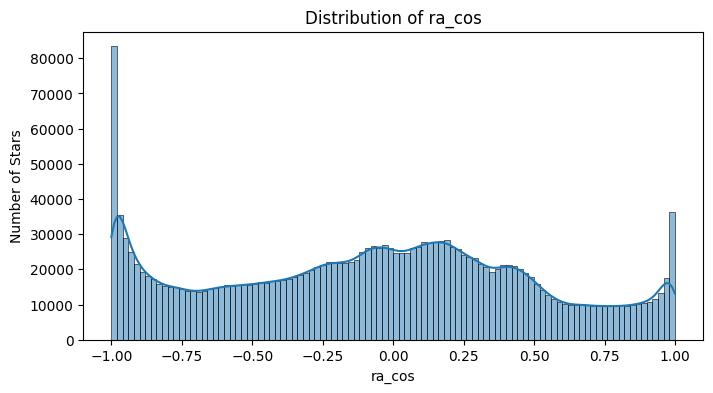

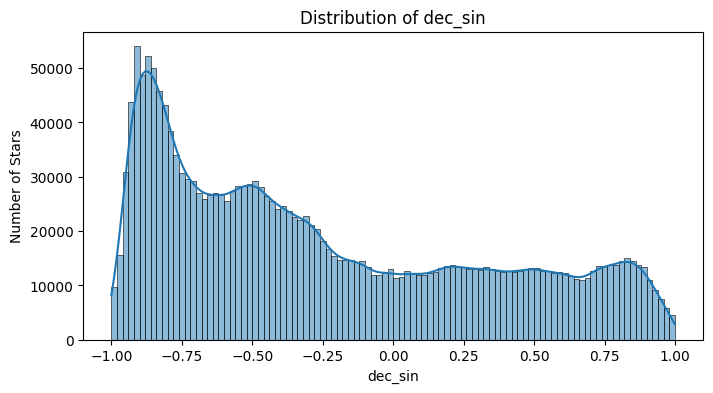

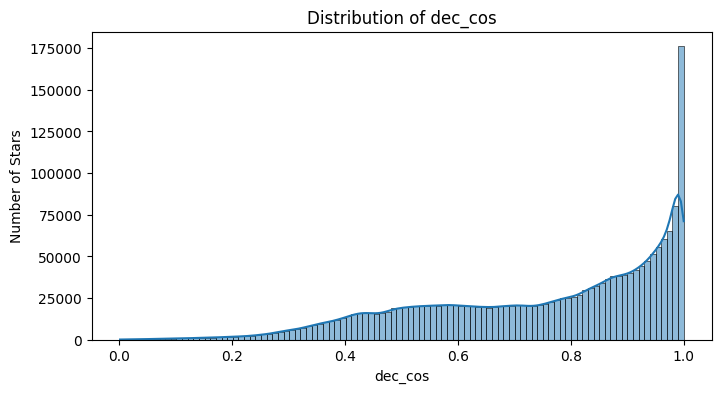

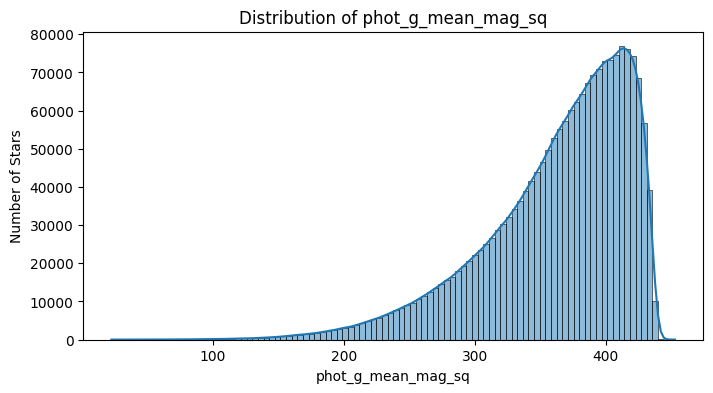

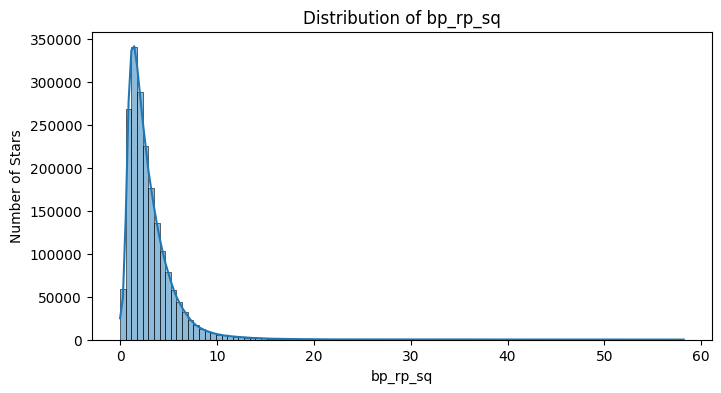

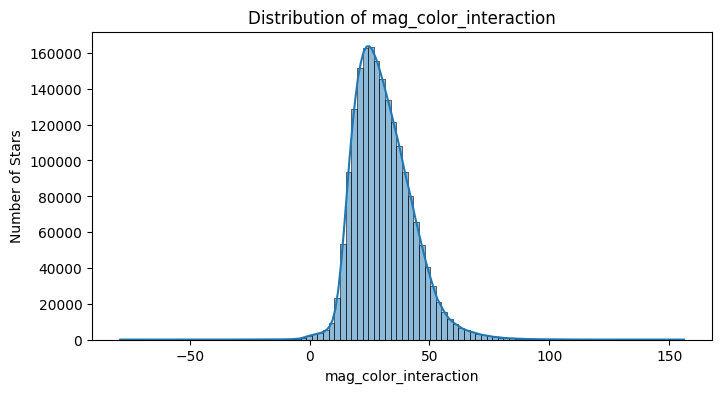

In [ ]:
# show the distributions of all machine learning input features.
for col in ml_feature_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(eda_df[col], bins=100, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Stars")
    plt.show()

Most features show some skewness rather than a perfectly symmetric distribution.
`phot_g_mean_mag` is mainly concentrated around 18–21, with fewer stars at lower magnitude values.
The squared features show a similar pattern because they are derived from the original features. The transformed position features `(ra_sin, ra_cos, dec_sin, and dec_cos)` range from −1 to 1 and have a more balanced distribution.

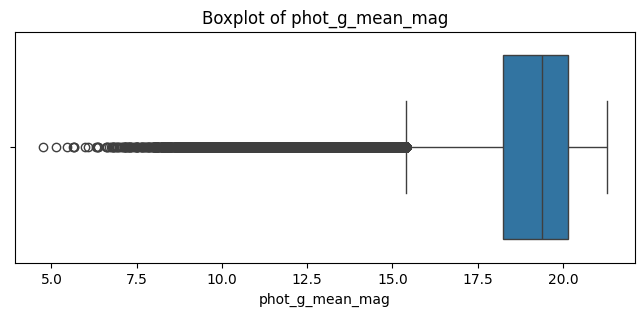

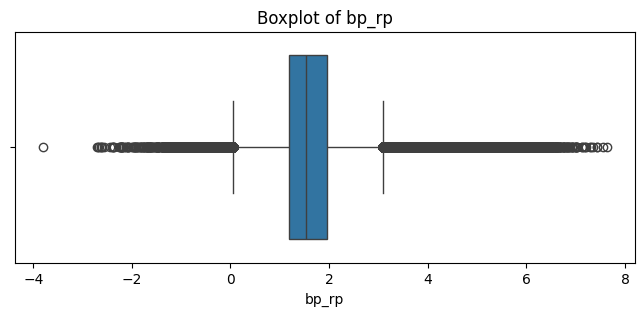

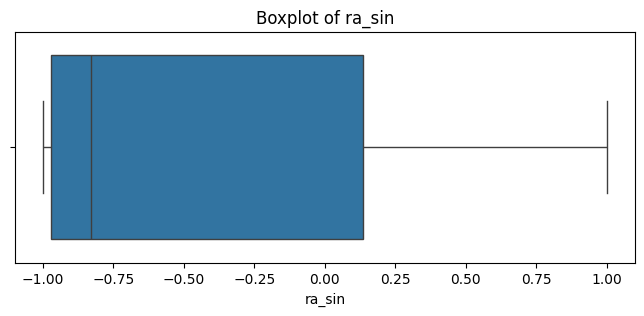

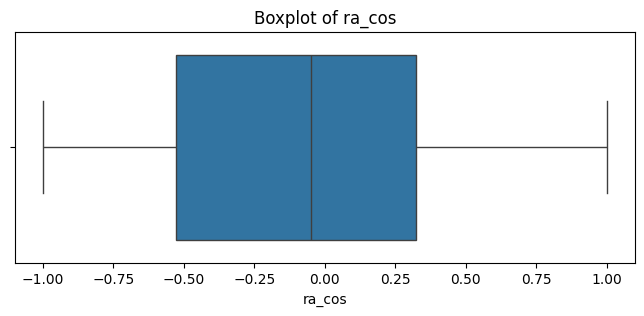

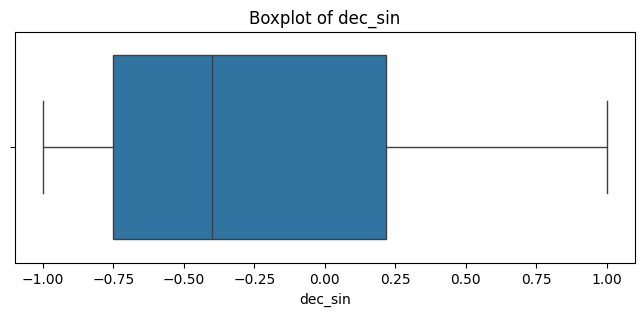

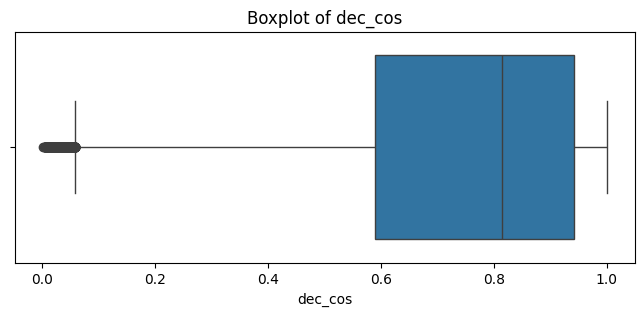

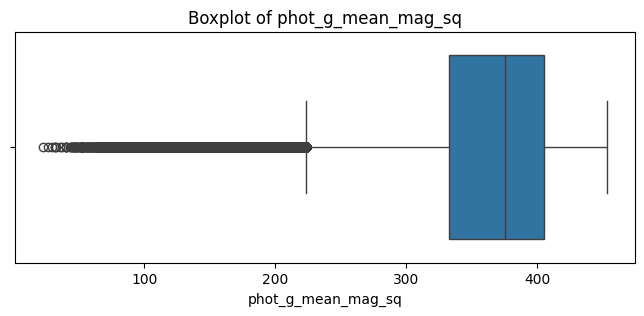

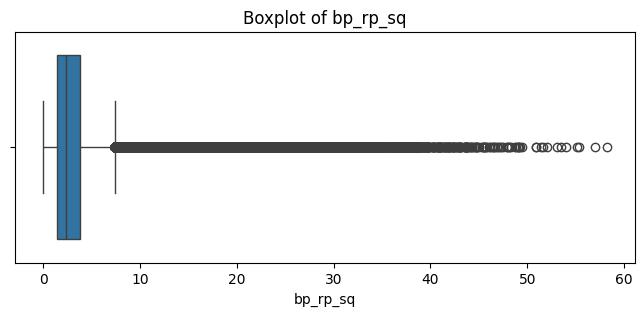

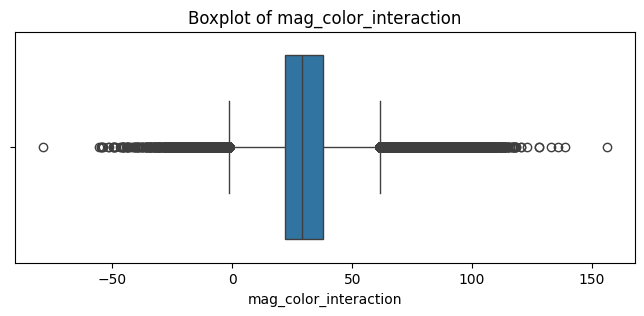

In [ ]:
# boxplot for معرفة توزيع the numbers outliers of the ML features.
for col in ml_feature_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=eda_df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [ ]:
# Count IQR-based for all ML features.
#These observations were not removed because extreme values can be valid measurements.
for col in ml_feature_cols:
    Q1 = eda_df[col].quantile(0.25)
    Q3 = eda_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = eda_df[(eda_df[col] < lower) | (eda_df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

phot_g_mean_mag: 65826 outliers
bp_rp: 45450 outliers
ra_sin: 0 outliers
ra_cos: 0 outliers
dec_sin: 0 outliers
dec_cos: 1050 outliers
phot_g_mean_mag_sq: 46498 outliers
bp_rp_sq: 89096 outliers
mag_color_interaction: 34099 outliers


`bp_rp_sq` has the highest number of IQR outliers (89,096), followed by `phot_g_mean_mag` (65,826).
This is mainly related to the spread and skewness of these features.

The outliers were kept because extreme values do not necessarily indicate errors. They may represent valid measurements of unusually bright, faint, red, or blue stars.

### 8.2 Non-ML feature EDA

In [ ]:
non_ml_cols = ["source_id", "ra", "dec"]

### 8.3 Quality Variables EDA

In [ ]:
eda_quality_cols = ["parallax_error","parallax_over_error", "ruwe"]

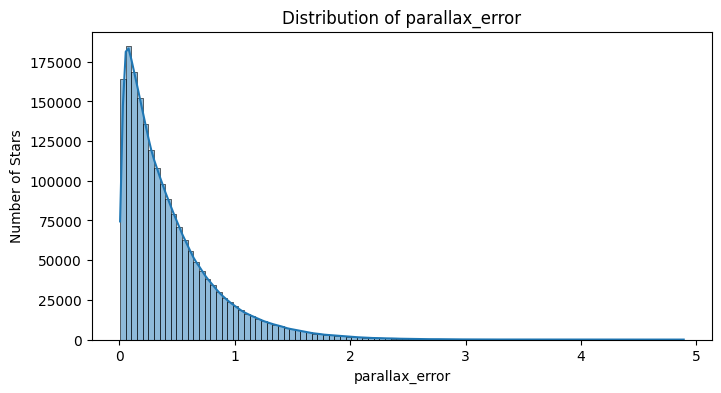

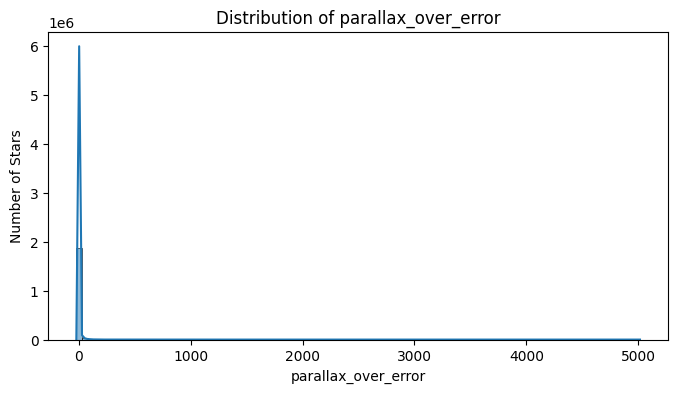

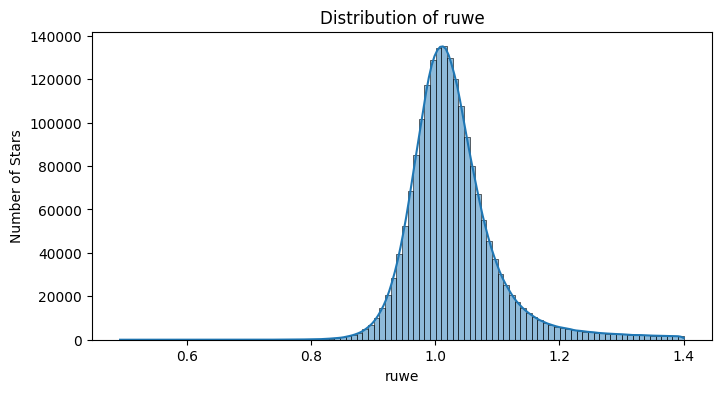

In [ ]:
# show the distributions of the astrometric quality indicators.
for col in eda_quality_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(eda_df[col], bins=100, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Stars")
    plt.show()

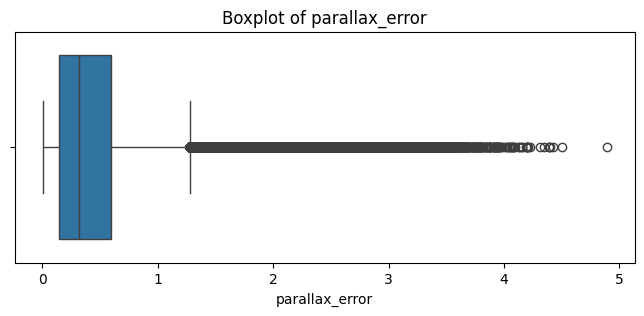

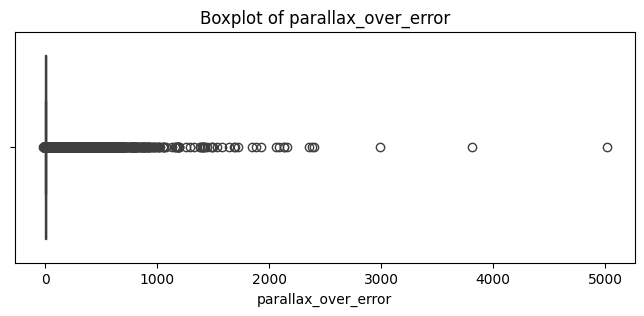

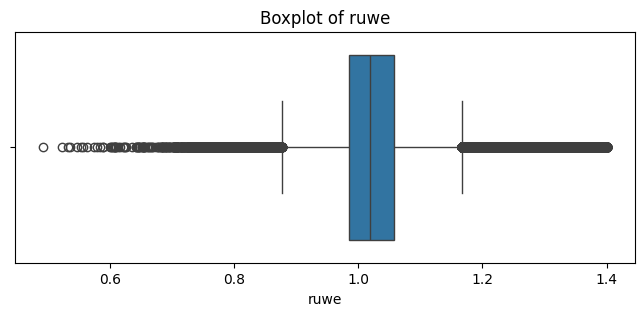

In [ ]:
# Boxplots for the quality variables.
for col in eda_quality_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=eda_df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [ ]:
# Count IQR-based for the quality variables.
for col in eda_quality_cols:
    Q1 = eda_df[col].quantile(0.25)
    Q3 = eda_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = eda_df[(eda_df[col] < lower) |(eda_df[col] > upper)]

    print(f"{col}: {len(outliers)}  outliers")

parallax_error: 88916  outliers
parallax_over_error: 204924  outliers
ruwe: 97034  outliers


The three quality indicators show different distributions.`parallax_error` and `parallax_over_error` have wider, right-skewed distributions, while `ruwe` is mainly concentrated around 1.0.

`parallax_over_error` has the widest range, with some values reaching around 5,000. These variables were used to examine the quality of Gaia's astrometric measurements and were not included as input features for the machine learning models.

####Parallax Error vs G-band Magnitude

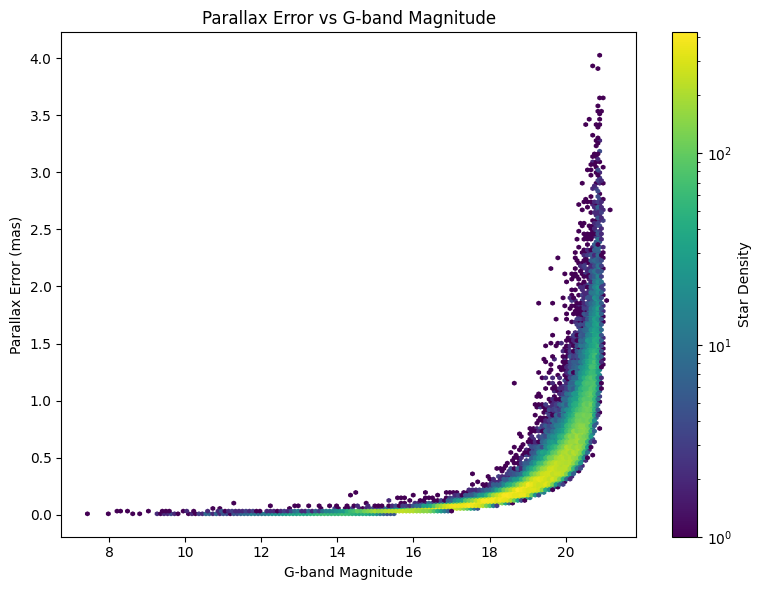

In [ ]:
# show how parallax uncertainty changes with stellar brightness

sample_quality = eda_df.sample(100000, random_state=42)

plt.figure(figsize=(8, 6))
plt.hexbin(
    sample_quality["phot_g_mean_mag"],
    sample_quality["parallax_error"],
    gridsize=150,
    bins="log",
    cmap="viridis"
)

plt.xlabel("G-band Magnitude")
plt.ylabel("Parallax Error (mas)")
plt.title("Parallax Error vs G-band Magnitude")
plt.colorbar(label="Star Density")
plt.tight_layout()
plt.show()

The plot shows a clear relationship between `phot_g_mean_mag` and `parallax_error`.

The parallax error remains relatively low for brighter stars and increases as the stars become fainter, especially at higher magnitude values.
This indicates that parallax measurements are generally less precise for faint stars. Since many observations in the dataset are faint stars, this measurement uncertainty is an important factor to consider when interpreting the model results and their relatively low R² values.

###8.4 ML Target EDA

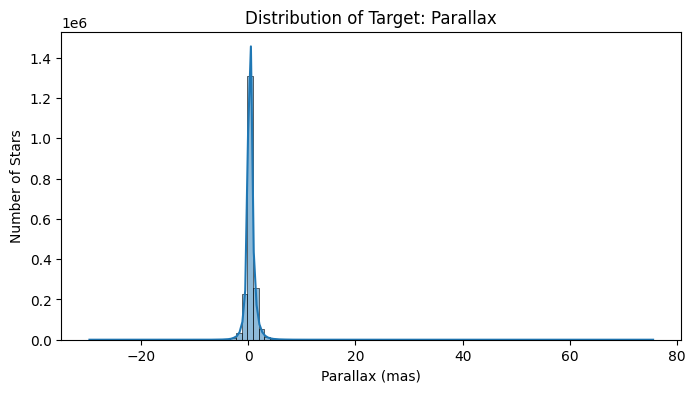

In [ ]:
# show the distributions of the ML target.
plt.figure(figsize=(8, 4))
sns.histplot(eda_df["parallax"],bins=100, kde=True)
plt.title("Distribution of Target: Parallax")
plt.xlabel("Parallax (mas)")
plt.ylabel("Number of Stars")
plt.show()

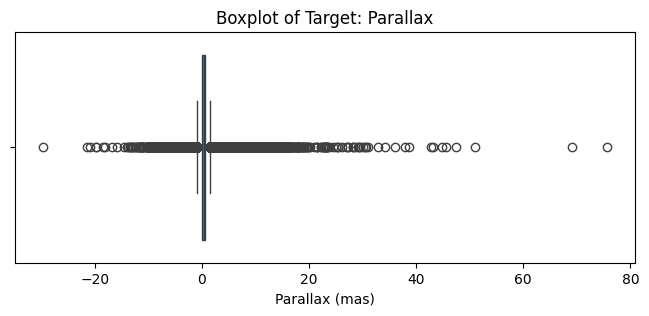

In [ ]:
# Boxplots for parallax.
plt.figure(figsize=(8, 3))
sns.boxplot(x=eda_df["parallax"])
plt.title("Boxplot of Target: Parallax")
plt.xlabel("Parallax (mas)")
plt.show()

In [ ]:
# Count IQR-based for parallax.
Q1 = eda_df["parallax"].quantile(0.25)
Q3 = eda_df["parallax"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

parallax_outliers = eda_df[(eda_df["parallax"] < lower) |(eda_df["parallax"] > upper)]

print(f"Parallax: {len(parallax_outliers)} outliers")

Parallax: 192014 outliers



The target variable `parallax` is highly concentrated near zero, with most values falling between −1 and 5 mas.  

A smaller number of stars have much higher parallax values, with the distribution extending to around 75 mas. The 192,014 IQR-flagged outliers were kept because these values can represent real nearby stars with higher parallax rather than data errors. This strong concentration near zero also helps explain why the models' predictions tend to cluster around zero.

In [ ]:
correlation_cols = [
    "phot_g_mean_mag",
    "bp_rp",
    "ra_sin",
    "ra_cos",
    "dec_sin",
    "dec_cos",
    "phot_g_mean_mag_sq",
    "bp_rp_sq",
    "mag_color_interaction",
    "parallax"
]

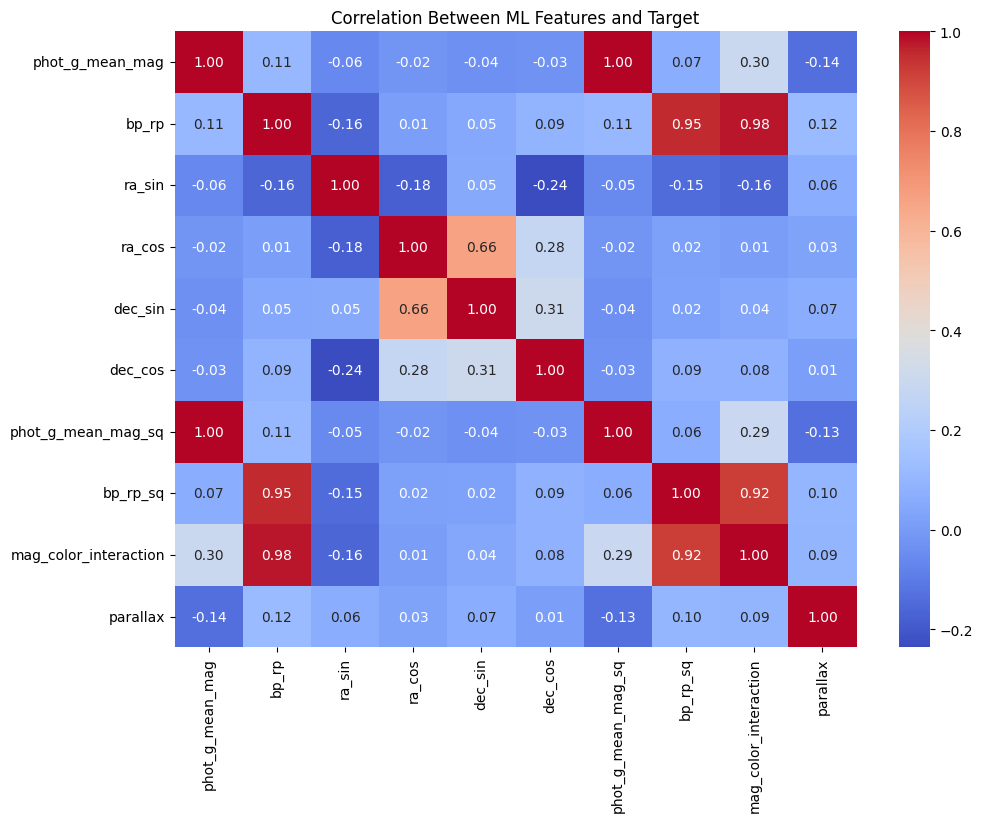

In [ ]:
plt.figure(figsize=(11, 8))
sns.heatmap(
    eda_df[correlation_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Between ML Features and Target")
plt.show()

The correlation heatmap shows an initial view of the linear relationships between the ML features and parallax. So these results are used as an initial analysis and are not the only basis for feature selection.


`bp_rp_sq` shows the strongest positive correlation with parallax (0.33), followed by `bp_rp` (0.29) and `mag_color_interaction` (0.22). `phot_g_mean_mag` shows a weaker negative correlation (-0.15).

The transformed sky-position features (`ra_sin`, `ra_cos`, `dec_sin`, and `dec_cos`) show very weak linear correlations with parallax.
Some engineered features are highly correlated with their original features, such as `phot_g_mean_mag_sq` with `phot_g_mean_mag` and `bp_rp_sq` with `bp_rp`. This is expected because these features are derived from the original variables.




###Figure 1. Color–Magnitude Diagram.


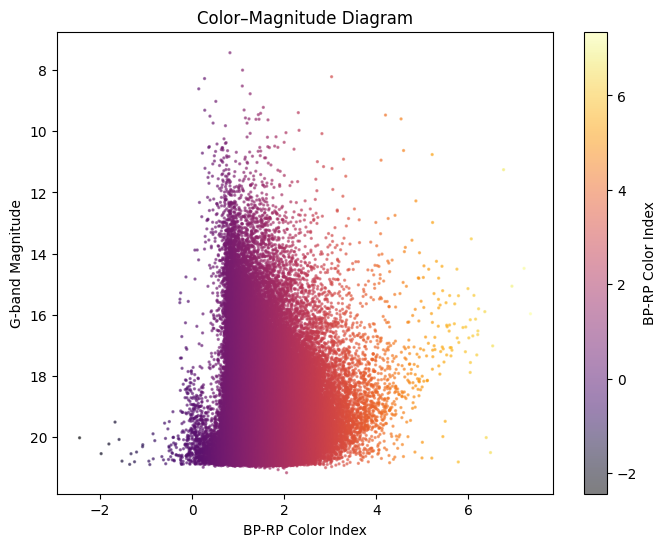

In [ ]:
# The Color–Magnitude Diagram compares stellar color with observed brightness.
#It helps show how the brightness and color variables are distributed together in the dataset.
# كيف تتوزع النجوم حسب اللون والسطوع؟

sample = eda_df.sample(100000, random_state=42)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    sample["bp_rp"],
    sample["phot_g_mean_mag"],
    c=sample["bp_rp"],
    cmap="inferno",
    s=2,
    alpha=0.5
)

plt.gca().invert_yaxis()

plt.colorbar(scatter, label="BP-RP Color Index")
plt.title("Color–Magnitude Diagram")
plt.xlabel("BP-RP Color Index")
plt.ylabel("G-band Magnitude")
plt.show()

This plot shows the distribution of Gaia sources by colour and observed brightness.
The BP-RP colour index is also used to colour the points, making differences in stellar colour easier to see. The plot helps us understand how colour and brightness are distributed together in the dataset.

### Figure 2. Color–Parallax density Diagram.


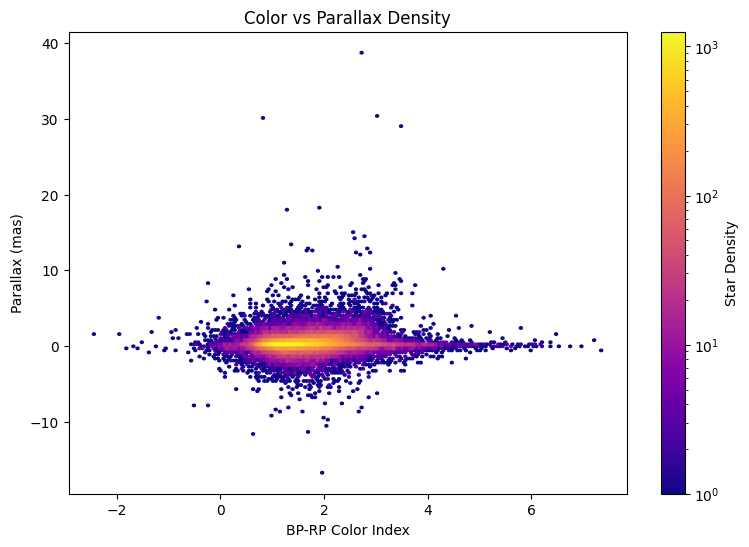

In [ ]:
#The Color–Parallax density plot examines the relationship between stellar color and the target (parallax).
#A density plot is used because the dataset contains many observations, making the main concentration of stars easier to see.
plt.figure(figsize=(9, 6))
plt.hexbin(
    sample["bp_rp"],
    sample["parallax"],
    gridsize=180,
    bins="log",
    cmap="plasma"
)
plt.xlabel("BP-RP Color Index")
plt.ylabel("Parallax (mas)")
plt.title("Color vs Parallax Density")
plt.colorbar(label="Star Density")
plt.show()

`Parallax` values are concentrated close to zero across most BP-RP color values.
The highest density is around BP-RP values of about 1–2, while larger parallax values appear less frequently. This shows that colour has some relationship with parallax, but the relationship is not strong enough to explain parallax on its own.

###Figure 3.Sky Density Map Diagram.


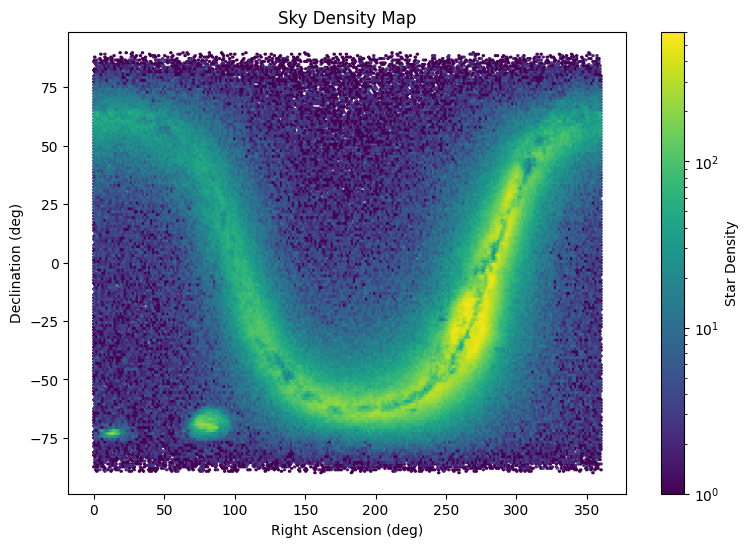

In [ ]:
# full-sky overview
#The sky density map shows how the selected Gaia resources are distributed across Right Ascension and Declination.
#It provides an overview of the spatial distribution of the dataset.
# أين توجد النجوم؟

plt.figure(figsize=(9, 6))
plt.hexbin(
    eda_df["ra"],
    eda_df["dec"],
    gridsize=250,
    bins="log",
    cmap="viridis"
)
plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.title("Sky Density Map")
plt.colorbar(label="Star Density")
plt.show()

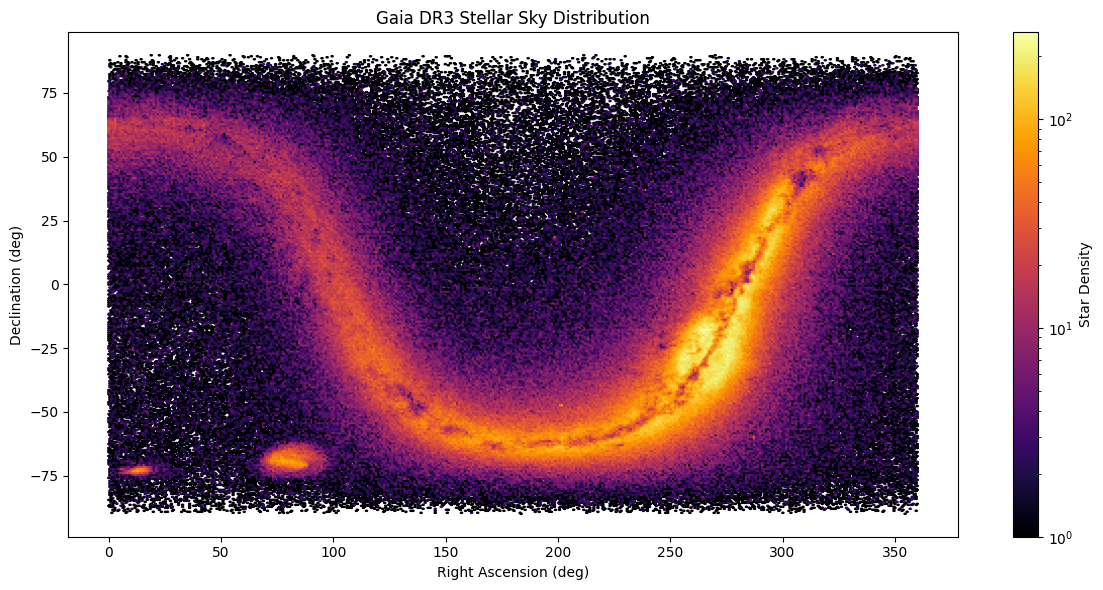

In [ ]:
# zoomed into the galactic plane
# Gaia DR3 Sky Map
# Shows the spatial distribution of the stars in the selected Gaia sample.
# Sky Density Map تشبة Milky Way-like(درب التبانة)، مكان العينة 2 مليون في مجرة درب التبانة

plt.figure(figsize=(12, 6))

plt.hexbin(
    eda_df["ra"],
    eda_df["dec"],
    gridsize=400,
    bins="log",
    cmap="inferno",
    mincnt=1
)

plt.xlabel("Right Ascension (deg)")
plt.ylabel("Declination (deg)")
plt.title("Gaia DR3 Stellar Sky Distribution")

plt.colorbar(label="Star Density")

plt.tight_layout()
plt.show()

The sky density map shows a clear dense band across the plot,
corresponding to the Milky Way, where stars are more concentrated. Two smaller high-density regions can also be seen around RA 10–90° and Dec −65° to −75°, which are consistent with the location of the **Magellanic Clouds**. The uneven distribution is expected in astronomical data because stars are naturally not distributed evenly across the sky.


 Magellanic Clouds are two dwarf galaxies orbiting our Milky Way. Being in our own galaxy, there are so many stars to see, especially near the Galactic Center

### 8.5 Distance and Absolute Magnitude Distribution EDA

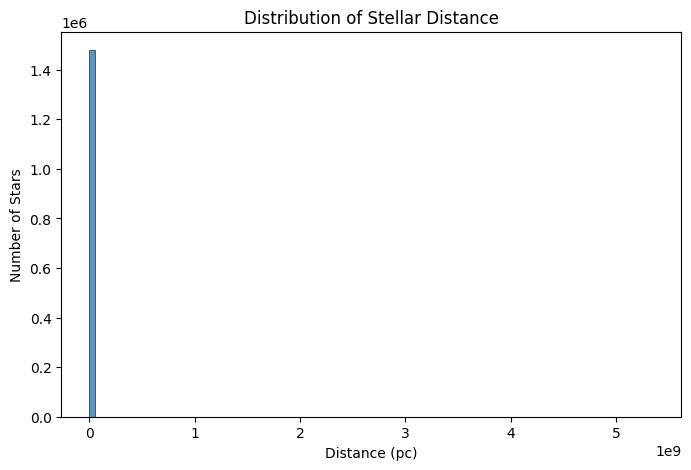

In [ ]:
#The distance distribution shows the range and concentration of stellar distances in the selected sample.
#It is used only for EDA because distance is calculated from parallax.
plt.figure(figsize=(8, 5))
sns.histplot(eda_df_positive["distance_pc"],bins=100)
plt.title("Distribution of Stellar Distance")
plt.xlabel("Distance (pc)")
plt.ylabel("Number of Stars")
plt.show()

The stellar distance distribution is strongly right-skewed, with most observations concentrated near the lower end of the distance range and a long tail toward larger distances.

This distribution is expected because distance was calculated from `parallax`, and small parallax values can result in very large estimated distances. This variable is used only for EDA and was not included as a machine learning feature.

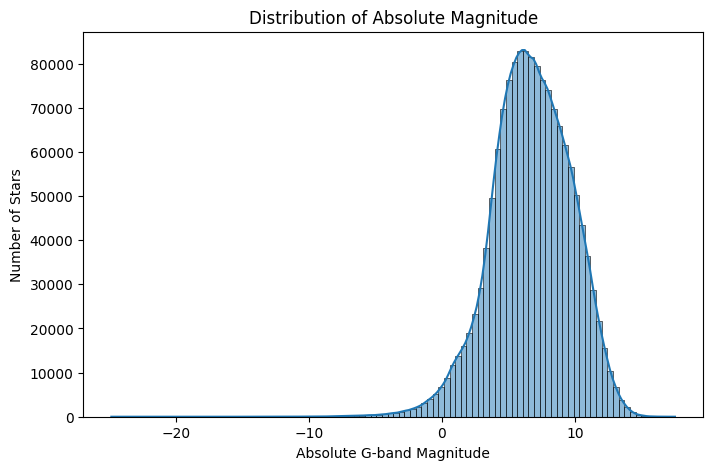

In [ ]:
#The absolute-magnitude distribution shows the range of intrinsic stellar brightness in the positive-parallax sample.
#It is used only for astronomical EDA because it is calculated from parallax.
plt.figure(figsize=(8, 5))
sns.histplot(
    eda_df_positive["absolute_magnitude"],
    bins=100,
    kde=True
)
plt.title("Distribution of Absolute Magnitude")
plt.xlabel("Absolute G-band Magnitude")
plt.ylabel("Number of Stars")
plt.show()


The absolute magnitude values are mainly concentrated around 5–10, with fewer stars at the lower and higher ends.

This shows the distribution of the stars' intrinsic brightness in the positive-parallax sample. Since absolute magnitude is calculated using parallax, it is used only for astronomical EDA and not as a machine learning feature.

###Figure 4. Gaia DR3 Hertzsprung–Russell Diagram.


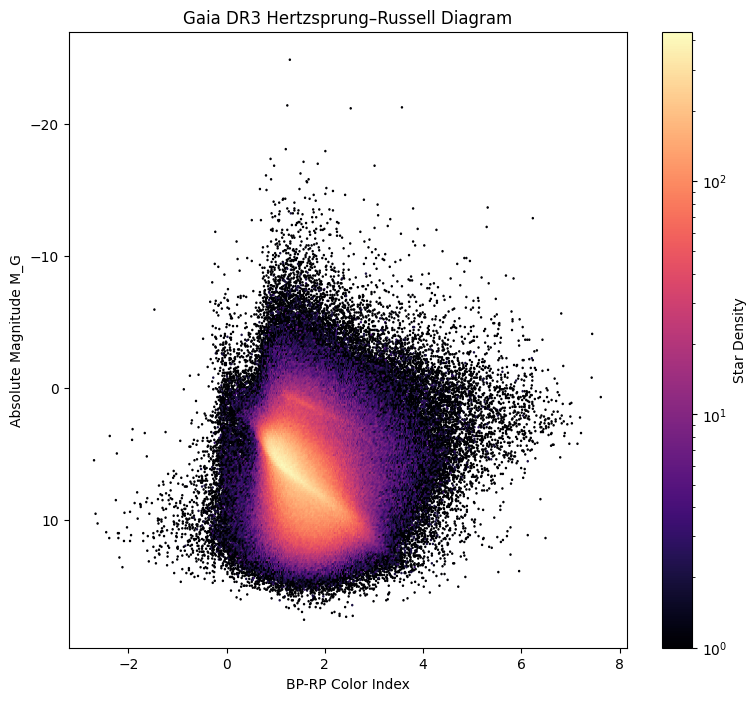

In [ ]:
# كيف تتوزع النجوم حسب اللون والسطوع المطلق؟

plt.figure(figsize=(9, 8))
plt.hexbin(
    eda_df_positive["bp_rp"],
    eda_df_positive["absolute_magnitude"],
    gridsize=500,
    bins="log",
    cmap="magma"
)
plt.gca().invert_yaxis()
plt.xlabel("BP-RP Color Index")
plt.ylabel("Absolute Magnitude M_G")
plt.title("Gaia DR3 Hertzsprung–Russell Diagram")
plt.colorbar(label="Star Density")
plt.show()

The Hertzsprung–Russell Diagram compares stellar color with intrinsic brightness. It helps visualize the main groups of stars present in the dataset and provides scientific validation of the sample. This plot is used only for EDA and is not part of the ML model.

###8.6 ML Features vs Target

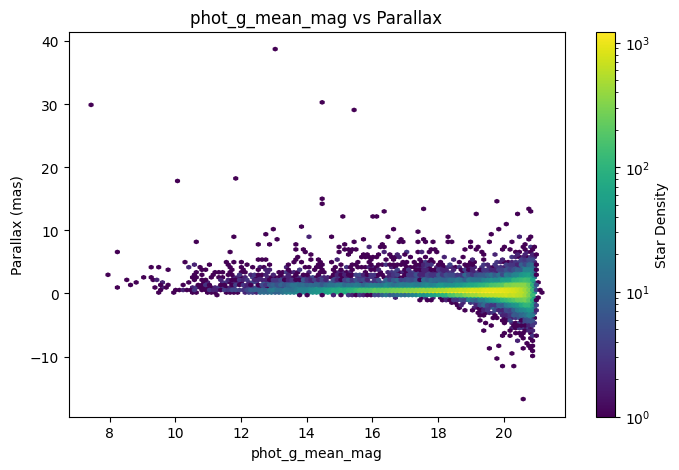

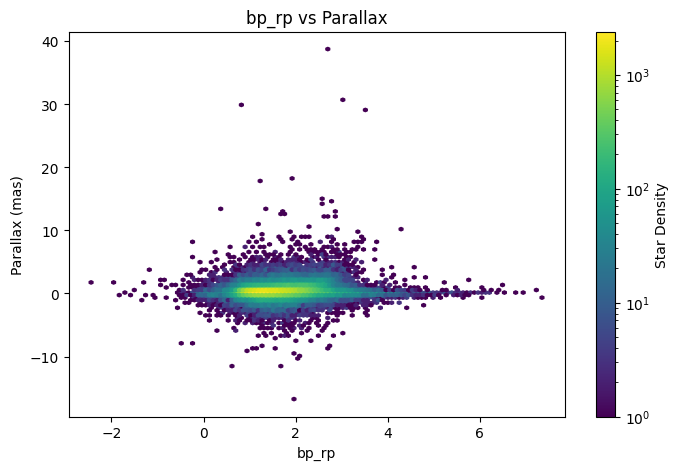

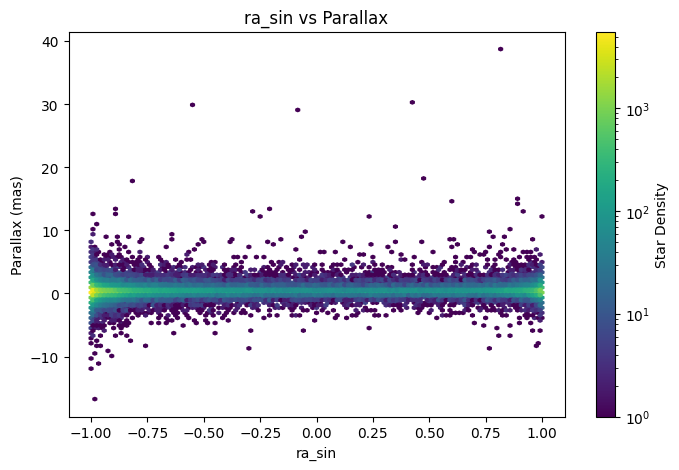

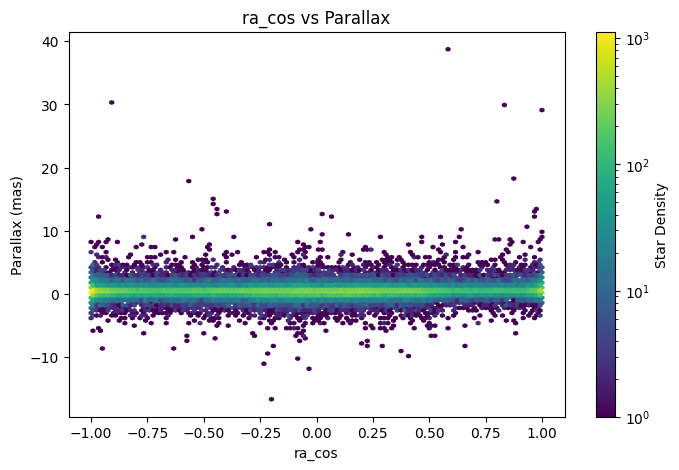

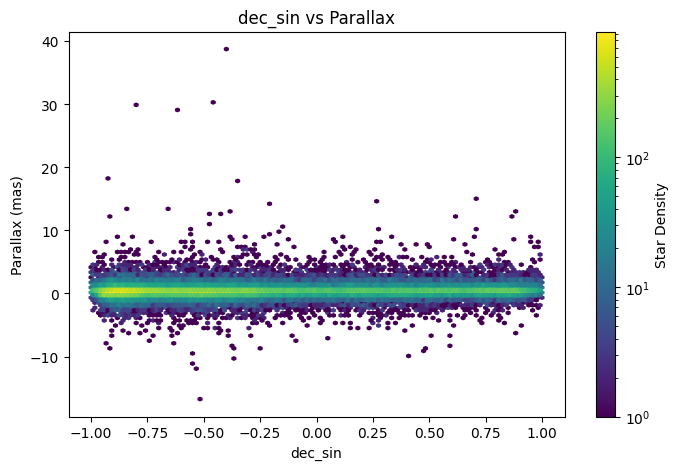

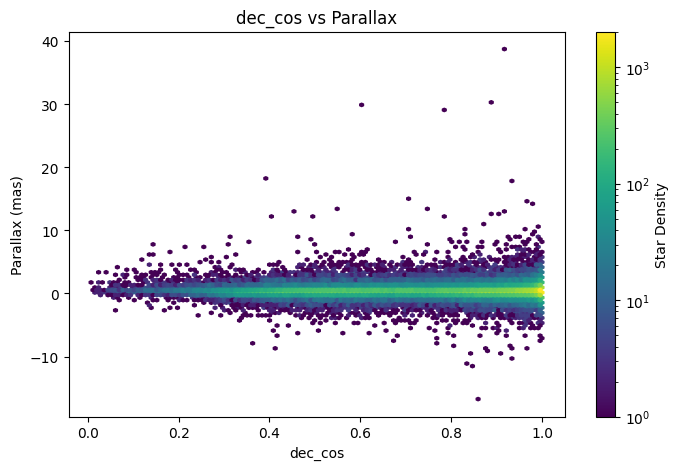

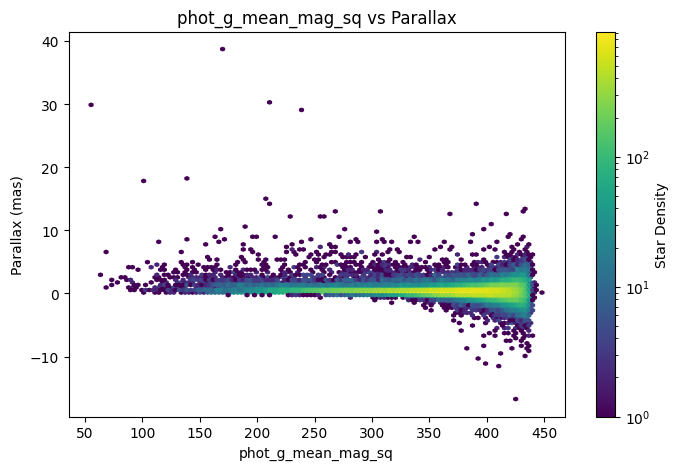

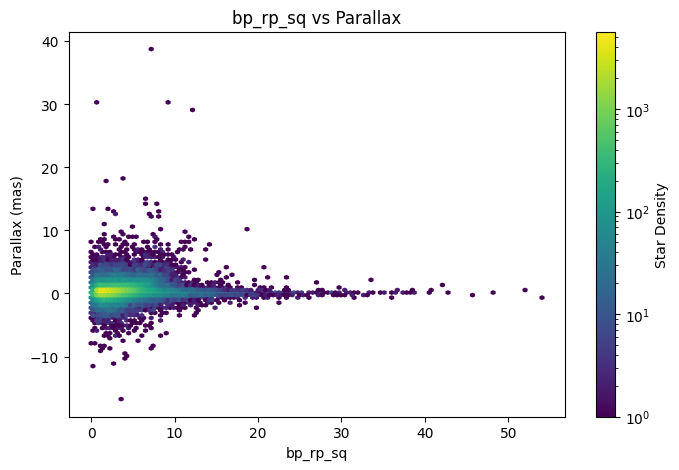

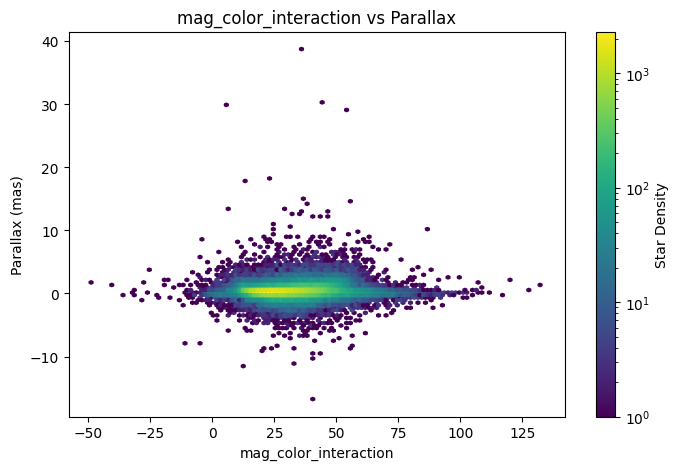

In [ ]:
# Show the relationship between each ML feature and the target.
sample = eda_df.sample(100000, random_state=42)
for col in ml_feature_cols:
    plt.figure(figsize=(8, 5))
    plt.hexbin(
        sample[col],
        sample["parallax"],
        gridsize=120,
        bins="log",
        cmap="viridis"
    )
    plt.xlabel(col)
    plt.ylabel("Parallax (mas)")
    plt.title(f"{col} vs Parallax")
    plt.colorbar(label="Star Density")
    plt.show()

The relationship between each machine learning feature and parallax was examined using density plots.
A density plot was used because the dataset contains a large number of observations, making the main patterns and concentration of the data easier to see.

### 8.7 Absolute Correlation with Target

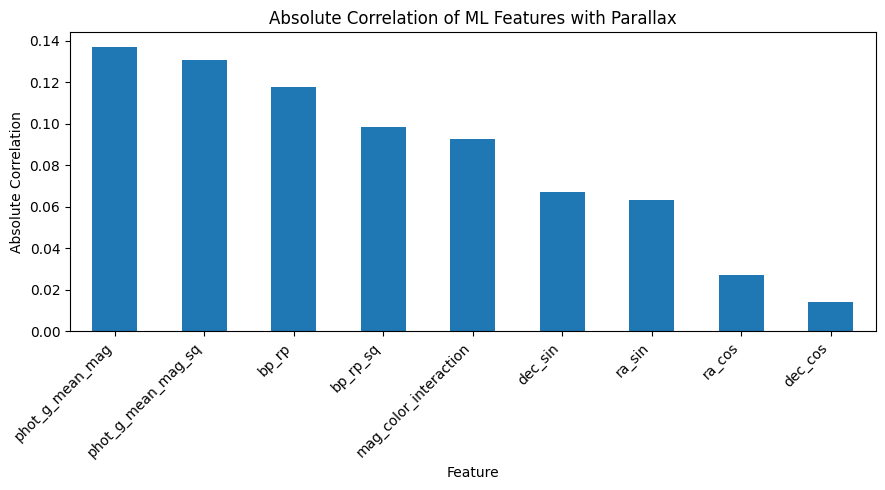

In [ ]:
# Calculate the absolute correlation of each ML feature with the target.
target_corr = (
    eda_df[ml_feature_cols + ["parallax"]]
    .corr()["parallax"]
    .drop("parallax")
    .abs()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
target_corr.plot(kind="bar")
plt.title("Absolute Correlation of ML Features with Parallax")
plt.xlabel("Feature")
plt.ylabel("Absolute Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

This plot compares the absolute correlation of the machine learning features with parallax.
It provides an initial comparison of their linear relationships with the target.
These results are later compared with the feature importance from the nonlinear models.

###8.8 Final EDA Feature Summary

In [ ]:
print("ML Features:",ml_feature_cols)
print("\nEDA-Only Quality Variables:",eda_quality_cols)
print("\nTarget: parallax")
print("\nAstronomical EDA Variables:",["distance_pc", "absolute_magnitude"])

ML Features: ['phot_g_mean_mag', 'bp_rp', 'ra_sin', 'ra_cos', 'dec_sin', 'dec_cos', 'phot_g_mean_mag_sq', 'bp_rp_sq', 'mag_color_interaction']

EDA-Only Quality Variables: ['parallax_error', 'parallax_over_error', 'ruwe']

Target: parallax

Astronomical EDA Variables: ['distance_pc', 'absolute_magnitude']


## 9.Feature Selection


In [ ]:
# input features for machine learning
X = gaia_clean[
    [
        "phot_g_mean_mag",
        "bp_rp",
        "ra_sin",
        "ra_cos",
        "dec_sin",
        "dec_cos",
        "phot_g_mean_mag_sq",
        "bp_rp_sq",
        "mag_color_interaction"
    ]
]

# the Target feature
y = gaia_clean["parallax"]

print("X Shape:", X.shape, "| y Shape:", y.shape)

X Shape: (1915241, 9) | y Shape: (1915241,)


## 10.Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)

X_train: (1532192, 9) | X_test: (383049, 9)
y_train: (1532192,) | y_test: (383049,)


## 11. Feature scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (1532192, 9)
X_test_scaled shape: (383049, 9)


##12.Models

###12.1  Model 1 — Linear Regression



In [ ]:
import time
import cupy as cp
from cuml.linear_model import LinearRegression

lr_model = LinearRegression()

# GPU statistics and training time
gpu_util_before, gpu_mem_before = get_gpu_stats()

cp.cuda.Stream.null.synchronize()
start_train = time.perf_counter()

lr_model.fit(X_train_scaled, y_train)

cp.cuda.Stream.null.synchronize()
end_train = time.perf_counter()
gpu_util_after, gpu_mem_after = get_gpu_stats()

lr_train_time = end_train - start_train

# GPU memory is measured after training.
# GPU utilization is only an instantaneous reading.
lr_gpu_util = gpu_util_after
lr_gpu_mem = gpu_mem_after

# Prediction time
cp.cuda.Stream.null.synchronize()
start_pred = time.perf_counter()

y_pred_lr = lr_model.predict(X_test_scaled)

cp.cuda.Stream.null.synchronize()
end_pred = time.perf_counter()

lr_prediction_time = end_pred - start_pred

print(f"Training Time: {lr_train_time:.4f} seconds")
print(f"Prediction Time: {lr_prediction_time:.4f} seconds")
print(f"GPU Utilization right after training: {lr_gpu_util}%")
print(f"GPU Memory used right after training: {lr_gpu_mem} MB")

Training Time: 2.5913 seconds
Prediction Time: 0.1023 seconds
GPU Utilization right after training: 57%
GPU Memory used right after training: 869 MB


###12.2 Model 2 — Random Forest Regression



In [ ]:
import time
import cupy as cp
from cuml.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=20, random_state=42)

# GPU statistics and training time
gpu_util_before, gpu_mem_before = get_gpu_stats()

cp.cuda.Stream.null.synchronize()
start_train = time.perf_counter()

rf_model.fit(X_train, y_train)

cp.cuda.Stream.null.synchronize()
end_train = time.perf_counter()

gpu_util_after, gpu_mem_after = get_gpu_stats()

rf_train_time = end_train - start_train
rf_gpu_util = gpu_util_after
rf_gpu_mem = gpu_mem_after

# Prediction time
cp.cuda.Stream.null.synchronize()
start_pred = time.perf_counter()

y_pred_rf = rf_model.predict(X_test)

cp.cuda.Stream.null.synchronize()
end_pred = time.perf_counter()

rf_prediction_time = end_pred - start_pred

print(f"Training Time: {rf_train_time:.4f} seconds")
print(f"Prediction Time: {rf_prediction_time:.4f} seconds")
print(f"GPU Utilization right after training: {rf_gpu_util}%")
print(f"GPU Memory used right after training: {rf_gpu_mem} MB")

Training Time: 38.4292 seconds
Prediction Time: 9.2984 seconds
GPU Utilization right after training: 0%
GPU Memory used right after training: 881 MB


###12.3 Model 3 — XGBoost Regression



In [ ]:
import time
import cupy as cp
import xgboost as xgb

# Feature names
feature_names = X.columns.tolist()

# Keep the data on the GPU
X_train_gpu = X_train.values
X_test_gpu = X_test.values
y_train_gpu = y_train.values
y_test_gpu = y_test.values

# Create XGBoost data matrices
dtrain = xgb.DMatrix(
    X_train_gpu,
    label=y_train_gpu,
    feature_names=feature_names
)

dtest = xgb.DMatrix(
    X_test_gpu,
    label=y_test_gpu,
    feature_names=feature_names
)

# XGBoost GPU configuration
xgb_params = {
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 8,
    "eta": 0.1,
    "objective": "reg:squarederror",
    "seed": 42
}

print("XGBoost version:", xgb.__version__)
print("Device: GPU (CUDA)")

# GPU statistics and training time

gpu_util_before, gpu_mem_before = get_gpu_stats()

cp.cuda.Stream.null.synchronize()
start_train = time.perf_counter()

xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round=200
)

cp.cuda.Stream.null.synchronize()
end_train = time.perf_counter()

gpu_util_after, gpu_mem_after = get_gpu_stats()

xgb_train_time = end_train - start_train
xgb_gpu_util = gpu_util_after
xgb_gpu_mem = gpu_mem_after

# Prediction time

cp.cuda.Stream.null.synchronize()
start_pred = time.perf_counter()

y_pred_xgb = xgb_model.predict(dtest)

cp.cuda.Stream.null.synchronize()
end_pred = time.perf_counter()

xgb_prediction_time = end_pred - start_pred

print(f"Training Time: {xgb_train_time:.4f} seconds")
print(f"Prediction Time: {xgb_prediction_time:.4f} seconds")
print(f"GPU Utilization reading after training: {xgb_gpu_util}%")
print(f"GPU Memory used after training: {xgb_gpu_mem} MB")

XGBoost version: 3.3.0
Device: GPU (CUDA)
Training Time: 3.1430 seconds
Prediction Time: 0.0535 seconds
GPU Utilization reading after training: 58%
GPU Memory used after training: 1603 MB


###12.4 Model 4 — K-Means

In [ ]:
# K-Means is used as an unsupervised analysis to examine whether observable stellar properties form meaningful groups.

import time
import cupy as cp
from cuml.cluster import KMeans
from cuml.preprocessing import StandardScaler

# Use leakage-safe observable features only
X_cluster = gaia_clean[["phot_g_mean_mag", "bp_rp"]]

# Scale features because K-Means is distance-based
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

# GPU statistics and clustering time

gpu_util_before, gpu_mem_before = get_gpu_stats()

cp.cuda.Stream.null.synchronize()
start_cluster = time.perf_counter()

kmeans_model = KMeans(n_clusters=4,random_state=42)

cluster_labels = kmeans_model.fit_predict(X_cluster_scaled)

cp.cuda.Stream.null.synchronize()
end_cluster = time.perf_counter()

gpu_util_after, gpu_mem_after = get_gpu_stats()

kmeans_time = end_cluster - start_cluster

print(f"Clustering Time: {kmeans_time:.4f} seconds")
print(f"GPU Utilization reading after clustering: {gpu_util_after}%")
print(f"GPU Memory used after clustering: {gpu_mem_after} MB")

Clustering Time: 1.1603 seconds
GPU Utilization reading after clustering: 49%
GPU Memory used after clustering: 1649 MB


K-Means was added as an unsupervised analysis to examine whether stars can be grouped using only observable properties such as brightness and colour. This provides a complementary analysis to the supervised regression models and helps investigate whether the observable features form groups that correspond to visible stellar populations.

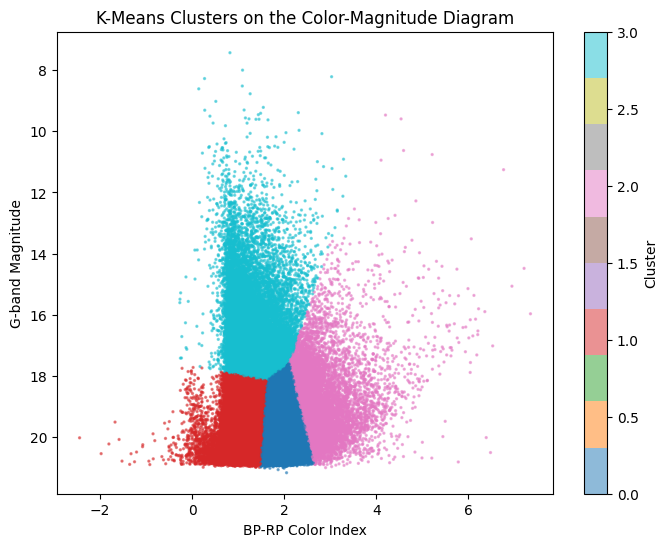

In [ ]:
# Visualize the K-Means clusters on the Color-Magnitude Diagram

# Convert only the data needed for visualization to Pandas
cluster_plot_df = X_cluster.to_pandas().copy()

# Convert cluster labels to a NumPy array for plotting
cluster_plot_df["cluster"] = cp.asnumpy(cluster_labels)

# Use a sample for clearer visualization
sample_clustered = cluster_plot_df.sample(n=100000,random_state=42)

# Plot the clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    sample_clustered["bp_rp"],
    sample_clustered["phot_g_mean_mag"],
    c=sample_clustered["cluster"],
    cmap="tab10",
    s=2,
    alpha=0.5
)

# Magnitude scale: brighter stars have smaller magnitude values
plt.gca().invert_yaxis()
plt.title("K-Means Clusters on the Color-Magnitude Diagram")
plt.xlabel("BP-RP Color Index")
plt.ylabel("G-band Magnitude")
plt.colorbar(label="Cluster")
plt.show()

The K-Means clusters are visualized on the Color-Magnitude Diagram using brightness and colour, the same observable properties used for clustering. Each colour represents a different cluster identified by K-Means. The plot helps us visually examine whether the unsupervised model separates stars into distinct groups in the colour–magnitude space.

##13.Evaluation

In [ ]:
from cuml.metrics import(mean_absolute_error, mean_squared_error, r2_score)

### 13.1 Model 1 - Linear Regression

In [ ]:
lr_mae = float(mean_absolute_error(y_test, y_pred_lr))
lr_mse = float(mean_squared_error(y_test, y_pred_lr))
lr_rmse = np.sqrt(lr_mse)
lr_r2 = float(r2_score(y_test, y_pred_lr))

print("Linear Regression")
print(f"MAE:  {lr_mae:.4f}")
print(f"RMSE: {lr_rmse:.4f}")
print(f"R²:   {lr_r2:.4f}")

Linear Regression
MAE:  0.5214
RMSE: 0.8647
R²:   0.0576


###13.2 Model 2 - Random Forest

In [ ]:
rf_mae = float(mean_absolute_error(y_test, y_pred_rf))
rf_mse = float(mean_squared_error(y_test, y_pred_rf))
rf_rmse = np.sqrt(rf_mse)
rf_r2 = float(r2_score(y_test, y_pred_rf))

print("Random Forest")
print(f"MAE:  {rf_mae:.4f}")
print(f"RMSE: {rf_rmse:.4f}")
print(f"R²:   {rf_r2:.4f}")

Random Forest
MAE:  0.4688
RMSE: 0.8063
R²:   0.1805


###13.3 Model 3 - XGBoost

In [ ]:
xgb_mae = float(mean_absolute_error(y_test_gpu, y_pred_xgb))
xgb_mse = float(mean_squared_error(y_test_gpu, y_pred_xgb))
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = float(r2_score(y_test_gpu, y_pred_xgb))

print("XGBoost")
print(f"MAE:  {xgb_mae:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"R²:   {xgb_r2:.4f}")

XGBoost
MAE:  0.4692
RMSE: 0.8003
R²:   0.1927


###13.4 Model Comparison

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae
    ],

    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "R2": [
        lr_r2,
        rf_r2,
        xgb_r2
    ],

    "Training Time (s)": [
        lr_train_time,
        rf_train_time,
        xgb_train_time
    ],

    "Prediction Time (s)": [
        lr_prediction_time,
        rf_prediction_time,
        xgb_prediction_time
    ],

    "GPU Utilization Reading (%)": [
        lr_gpu_util,
        rf_gpu_util,
        xgb_gpu_util
    ],

    "GPU Memory Reading (MB)": [
        lr_gpu_mem,
        rf_gpu_mem,
        xgb_gpu_mem
    ]
})

results

,Model,MAE,RMSE,R2,Training Time (s),Prediction Time (s),GPU Utilization Reading (%),GPU Memory Reading (MB)
0,Linear Regression,0.521430,0.864699,0.057603,2.591250,0.102328,57,869
1,Random Forest,0.468816,0.806333,0.180530,38.429239,9.298401,0,881
2,XGBoost,0.469180,0.800312,0.192724,3.143031,0.053460,58,1603


In [ ]:
# ترتيب النماذج حسب RMSE
results_sorted = results.sort_values(by="RMSE",ascending=True)
results_sorted

,Model,MAE,RMSE,R2,Training Time (s),Prediction Time (s),GPU Utilization Reading (%),GPU Memory Reading (MB)
2,XGBoost,0.469180,0.800312,0.192724,3.143031,0.053460,58,1603
1,Random Forest,0.468816,0.806333,0.180530,38.429239,9.298401,0,881
0,Linear Regression,0.521430,0.864699,0.057603,2.591250,0.102328,57,869


In [ ]:
# show the أفضل نموذج
best_model = results_sorted.iloc[0]

print("Best Predictive Model:")
print(best_model)

Best Predictive Model:
Model                           XGBoost
MAE                             0.46918
RMSE                           0.800312
R2                             0.192724
Training Time (s)              3.143031
Prediction Time (s)             0.05346
GPU Utilization Reading (%)          58
GPU Memory Reading (MB)            1603
Name: 2, dtype: object


##13.5 Actual vs Predicted

In [ ]:
def to_host(arr):
    """Convert GPU arrays/Series to NumPy arrays for visualization."""
    if hasattr(arr, "to_numpy"):
        return arr.to_numpy()
    if hasattr(arr, "get"):
        return arr.get()
    return np.asarray(arr)

In [ ]:
y_test_host = to_host(y_test)

predictions = {
    "Linear Regression": to_host(y_pred_lr),
    "Random Forest": to_host(y_pred_rf),
    "XGBoost": to_host(y_pred_xgb)
}

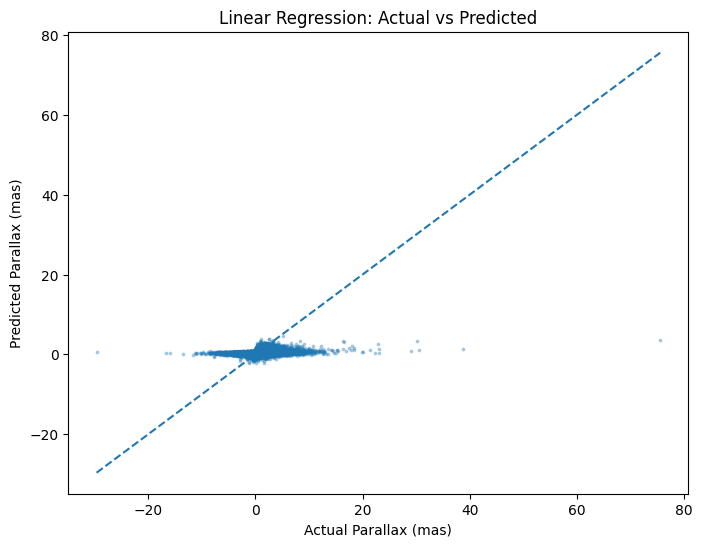

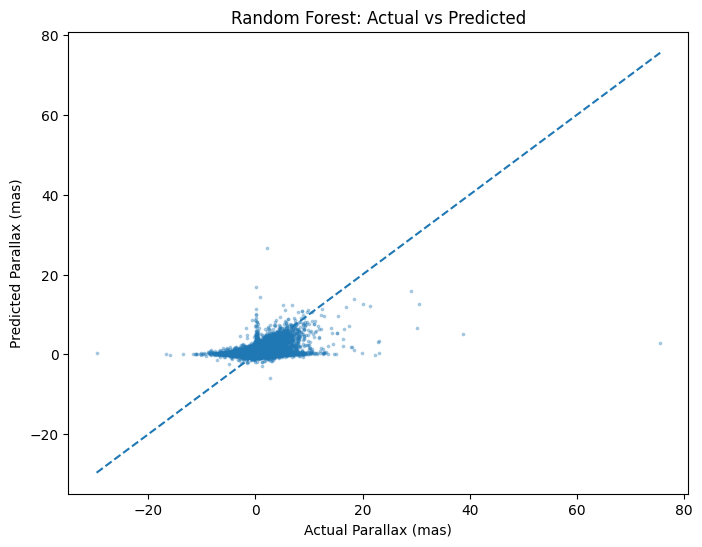

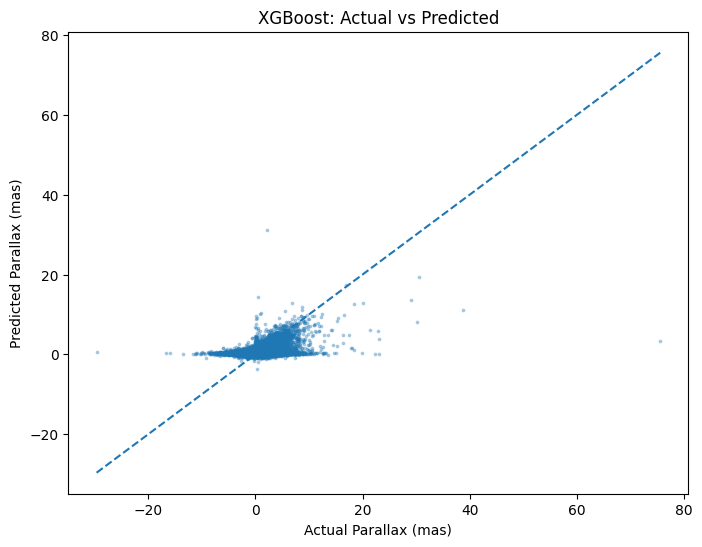

In [ ]:
for model_name, predictions_host in predictions.items():

    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_host,predictions_host,s=3,alpha=0.3)

    # Ideal prediction line
    min_value = min(y_test_host.min(),predictions_host.min())

    max_value = max(y_test_host.max(),predictions_host.max())

    plt.plot([min_value, max_value],[min_value, max_value],linestyle="--")

    plt.xlabel("Actual Parallax (mas)")
    plt.ylabel("Predicted Parallax (mas)")
    plt.title(f"{model_name}: Actual vs Predicted")
    plt.show()

## 13.6 Residual Analysis
Residual=Actual−Predicted

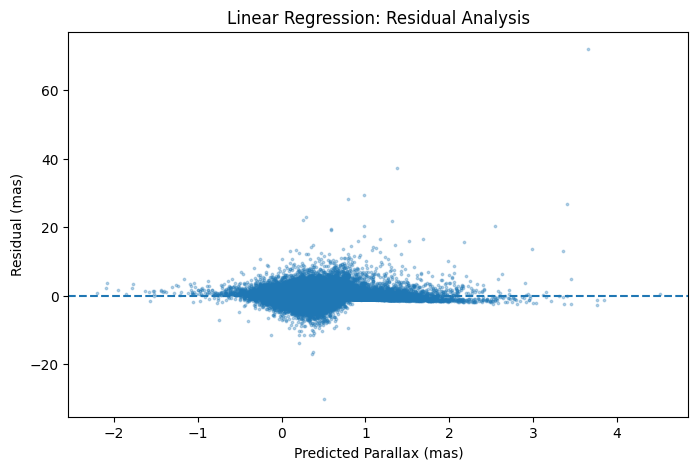

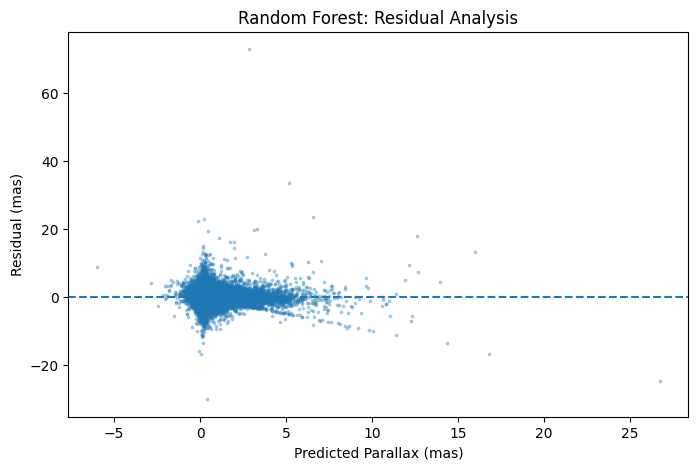

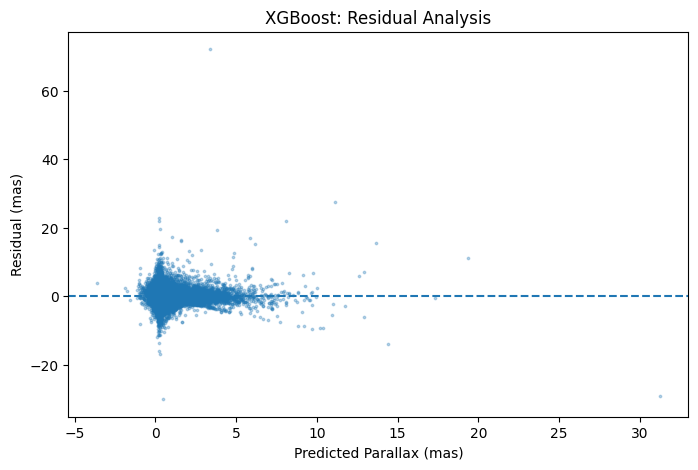

In [ ]:
for model_name, predictions_host in predictions.items():

    residuals = y_test_host - predictions_host
    plt.figure(figsize=(8, 5))

    plt.scatter(predictions_host,residuals,s=3,alpha=0.3)
    plt.axhline(0,linestyle="--")

    plt.xlabel("Predicted Parallax (mas)")
    plt.ylabel("Residual (mas)")
    plt.title(f"{model_name}: Residual Analysis")
    plt.show()

####Residual Distribution

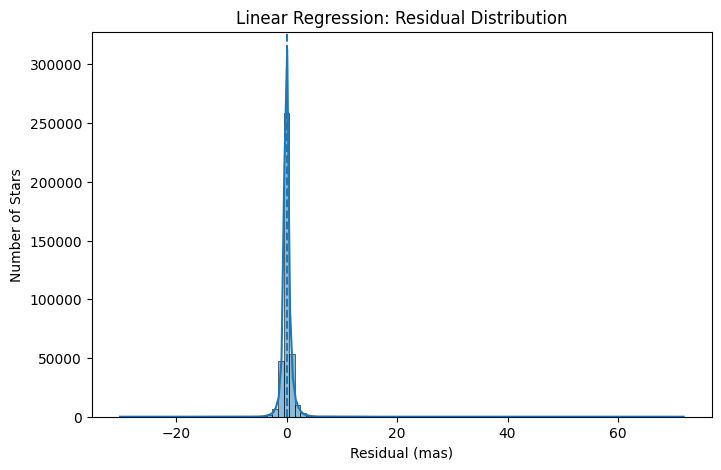

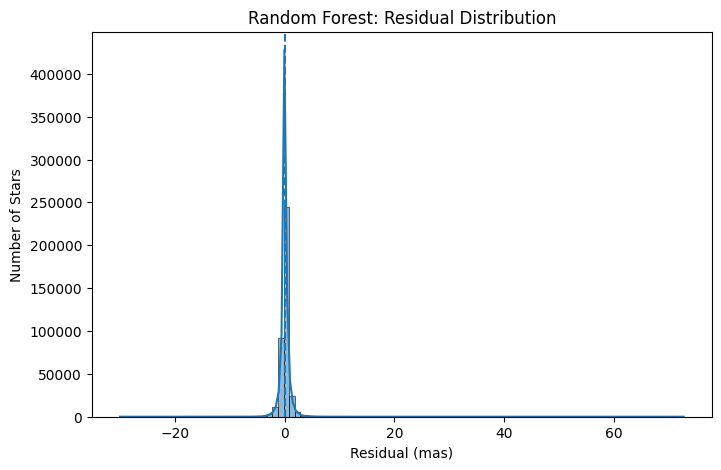

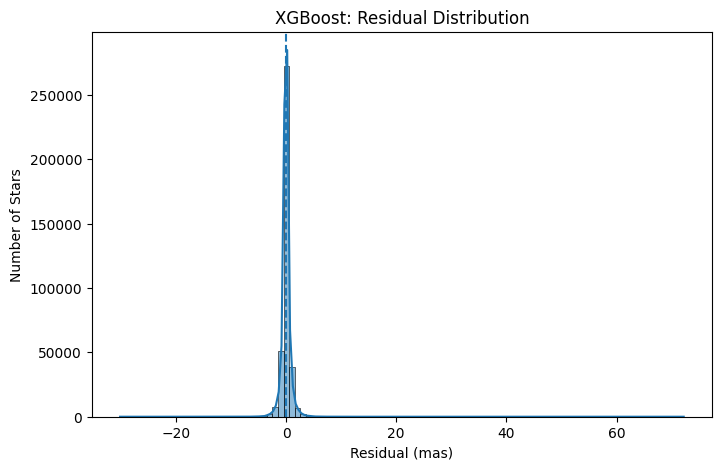

In [ ]:
for model_name, predictions_host in predictions.items():

    residuals = y_test_host - predictions_host

    plt.figure(figsize=(8, 5))
    sns.histplot(residuals,bins=100,kde=True)
    plt.axvline( 0,linestyle="--")

    plt.xlabel("Residual (mas)")
    plt.ylabel("Number of Stars")
    plt.title(f"{model_name}: Residual Distribution")
    plt.show()

## 13.7 Model Comparison — R²

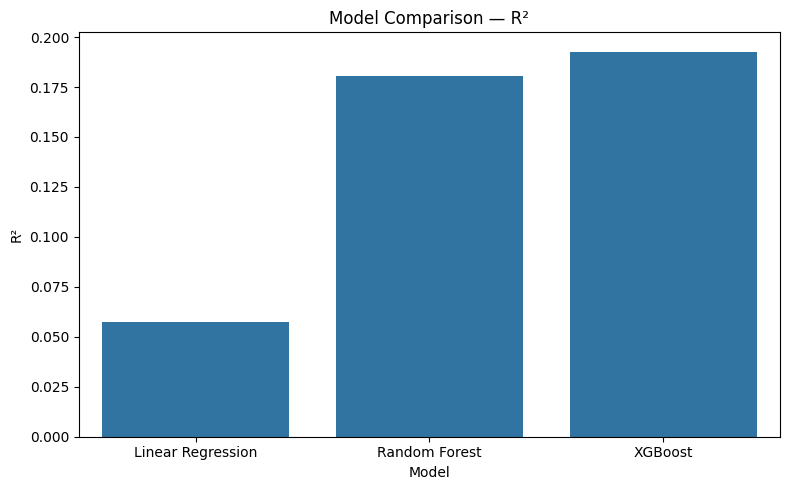

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(data=results,x="Model",y="R2")

plt.title("Model Comparison — R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.tight_layout()
plt.show()

## 13.8 Model Comparison — RMSE

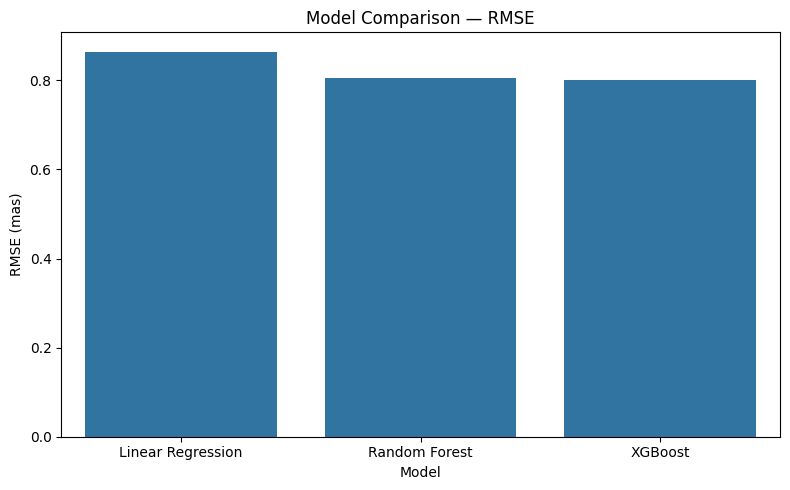

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(data=results,x="Model",y="RMSE")

plt.title("Model Comparison — RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE (mas)")
plt.tight_layout()
plt.show()

## 13.9 Training Time Comparison

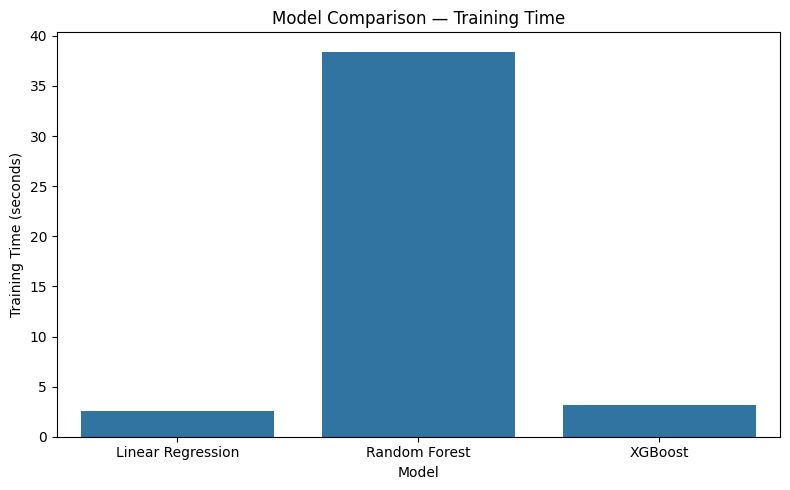

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(data=results,x="Model",y="Training Time (s)")

plt.title("Model Comparison — Training Time")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.tight_layout()
plt.show()

##13.10 Prediction Time Comparison

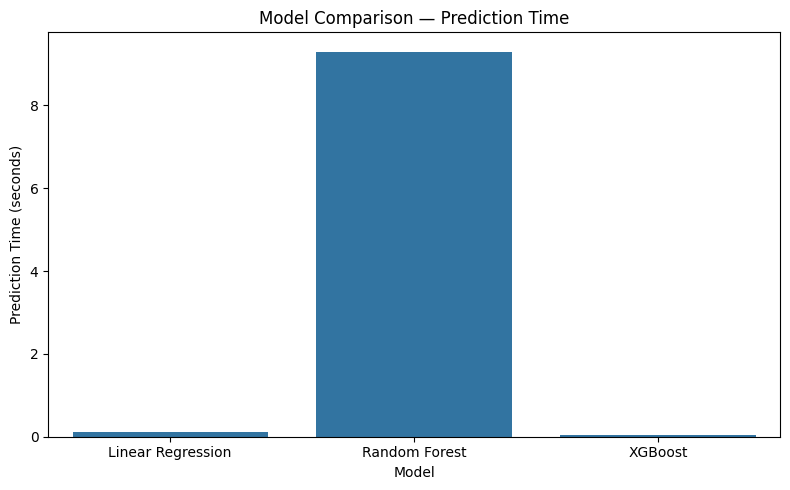

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(data=results,x="Model",y="Prediction Time (s)")

plt.title("Model Comparison — Prediction Time")
plt.xlabel("Model")
plt.ylabel("Prediction Time (seconds)")
plt.tight_layout()
plt.show()

### 13.11 Feature Importance — Random Forest
Which observable features are most strongly associated with parallax?

In [ ]:
feature_names = list(X.columns)

rf_importance = to_host(rf_model.feature_importances_)

rf_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_importance
}).sort_values(by="Importance",ascending=False)

rf_feature_importance

,Feature,Importance
6,phot_g_mean_mag_sq,0.197689
5,dec_cos,0.145933
3,ra_cos,0.123814
2,ra_sin,0.123174
8,mag_color_interaction,0.117835
7,bp_rp_sq,0.115246
4,dec_sin,0.081294
1,bp_rp,0.065456
0,phot_g_mean_mag,0.029558


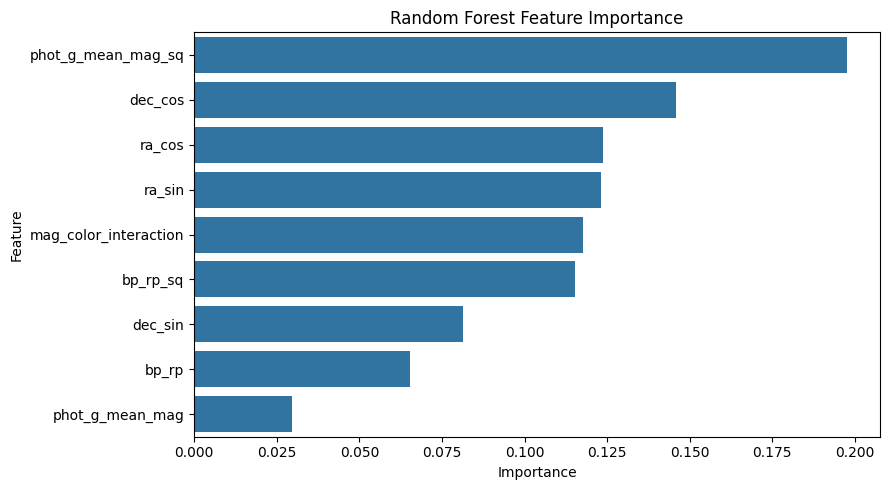

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(data=rf_feature_importance,x="Importance",y="Feature")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### 13.12 Feature Importance — XGBoost

In [ ]:
# Measure feature importance using the average gain from tree splits.

xgb_gain = xgb_model.get_score(importance_type="gain")

xgb_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": [
        xgb_gain.get(feature, 0)
        for feature in feature_names
    ]
}).sort_values(by="Importance",ascending=False)

xgb_feature_importance

,Feature,Importance
1,bp_rp,62.429913
0,phot_g_mean_mag,52.840569
7,bp_rp_sq,48.962517
5,dec_cos,43.152706
2,ra_sin,40.412834
4,dec_sin,35.184696
3,ra_cos,33.117184
8,mag_color_interaction,27.431536
6,phot_g_mean_mag_sq,0.000000


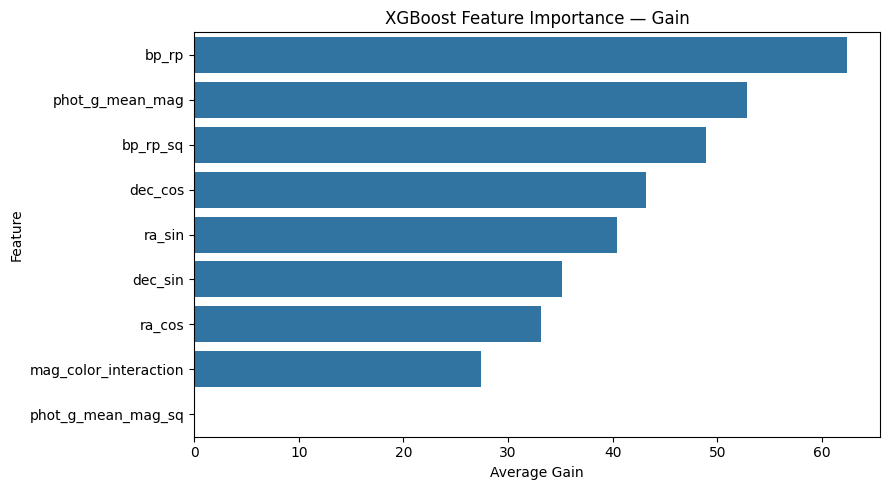

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(data=xgb_feature_importance,x="Importance",y="Feature")

plt.title("XGBoost Feature Importance — Gain")
plt.xlabel("Average Gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

A difference between the two models is that phot_g_mean_mag_sq was the most important feature for Random Forest, while XGBoost assigned it zero gain.







##14. Hyperparameter Tuning

The XGBoost model was further tested by changing the learning rate and number of boosting rounds.
**The learning rate was reduced from 0.1 to 0.03, while the number of boosting rounds was increased from 200 to 500 and keeping max_depth=8.**

The goal was to allow the model to learn more gradually and check whether these changes could improve the prediction performance.

In [ ]:
xgb_tuned_params = {
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 8,
    "eta": 0.03,
    "objective": "reg:squarederror",
    "seed": 42
}

xgb_tuned = xgb.train(
    xgb_tuned_params,
    dtrain,
    num_boost_round=500
)

y_pred_xgb_tuned = xgb_tuned.predict(dtest)

xgb_tuned_mae = float(
    mean_absolute_error(y_test_gpu, y_pred_xgb_tuned)
)

xgb_tuned_rmse = float(
    np.sqrt(mean_squared_error(y_test_gpu, y_pred_xgb_tuned))
)

xgb_tuned_r2 = float(
    r2_score(y_test_gpu, y_pred_xgb_tuned)
)

print("Tuned XGBoost")
print(f"MAE:  {xgb_tuned_mae:.4f}")
print(f"RMSE: {xgb_tuned_rmse:.4f}")
print(f"R²:   {xgb_tuned_r2:.4f}")

Tuned XGBoost
MAE:  0.4692
RMSE: 0.7991
R²:   0.1952


The tuned model slightly improved the results, reducing RMSE from 0.8003 to 0.7991 and increasing R² from 0.1927 to 0.1952. The MAE remained almost the same at 0.4692.

## 15.Baseline

In [ ]:
baseline_pred = cp.full(y_test.shape, y_train.mean())
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

In [ ]:
print("Baseline")
print(f"MAE:  {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R²:   {baseline_r2:.4f}")

Baseline
MAE:  0.5322
RMSE: 0.8907
R²:   -0.0000


A mean prediction baseline was used as a simple reference for the regression models. The baseline predicts the mean parallax from the training set for every test observation.

The baseline achieved a MAE of 0.5322, RMSE of 0.8907, and R² of approximately 0.0000. These results provide a reference point for evaluating whether the machine learning models improve over simply predicting the average parallax.



## 16. Cross-Validation — for the Best Model

Cross-validation is used to check whether the model performs consistently across different subsets of the data.

The dataset is divided into five folds, where each fold is used once for validation while the remaining folds are used for training.

The mean RMSE represents the overall validation performance, while the standard deviation shows how much the performance changes between folds.

In [ ]:
from sklearn.model_selection import KFold
import numpy as np
import cudf
from cuml.metrics import mean_squared_error

# Select the best model based on the lowest test RMSE
best_model_name = best_model["Model"]

print("Model selected for Cross-Validation:", best_model_name)

Model selected for Cross-Validation: XGBoost


In [ ]:
# Define the selected model using the same parameters
if best_model_name == "Linear Regression":
    model_class = LinearRegression
    model_params = {}

elif best_model_name == "Random Forest":
    model_class = RandomForestRegressor
    model_params = {
        "n_estimators": 100,
        "max_depth": 20,
        "random_state": 42
    }

elif best_model_name == "XGBoost":
    model_class = xgb.XGBRegressor
    model_params = {
        "n_estimators": 200,
        "max_depth": 8,
        "learning_rate": 0.1,
        "objective": "reg:squarederror",
        "random_state": 42,
        "tree_method": "hist",
        "device": "cuda"
    }

In [ ]:
# 5-fold cross-validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_rmses = []

# Convert only the indexing arrays to CPU
X_np = X.to_pandas().values
y_np = y.to_pandas().values

for fold, (train_idx, val_idx) in enumerate(kf.split(X_np), start=1):

    # Create GPU data for the current fold
    X_fold_train = cudf.DataFrame(
        X_np[train_idx],
        columns=X.columns
    )

    X_fold_val = cudf.DataFrame(
        X_np[val_idx],
        columns=X.columns
    )

    y_fold_train = cudf.Series(y_np[train_idx])
    y_fold_val = cudf.Series(y_np[val_idx])

    # Create a new model for this fold
    model = model_class(**model_params)

    # Train
    model.fit(X_fold_train, y_fold_train)

    # Predict
    predictions = model.predict(X_fold_val)

    # Calculate RMSE
    rmse = mean_squared_error(
        y_fold_val,
        predictions
    ) ** 0.5

    fold_rmses.append(float(rmse))

    print(f"Fold {fold}: RMSE = {rmse:.4f}")

# Overall CV result
cv_mean = np.mean(fold_rmses)
cv_std = np.std(fold_rmses)

print("\nCross-Validation Results")
print(f"Mean RMSE: {cv_mean:.4f}")
print(f"Standard Deviation: {cv_std:.4f}")

Fold 1: RMSE = 0.8003
Fold 2: RMSE = 0.8011
Fold 3: RMSE = 0.8004
Fold 4: RMSE = 0.7927
Fold 5: RMSE = 0.7882

Cross-Validation Results
Mean RMSE: 0.7966
Standard Deviation: 0.0052


## 17. Final Model Comparison

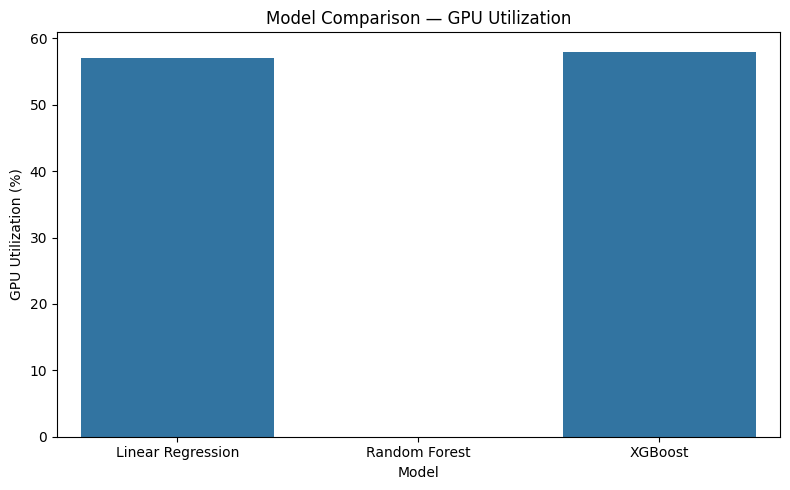

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="GPU Utilization Reading (%)"
)

plt.title("Model Comparison — GPU Utilization")
plt.xlabel("Model")
plt.ylabel("GPU Utilization (%)")

plt.tight_layout()
plt.show()

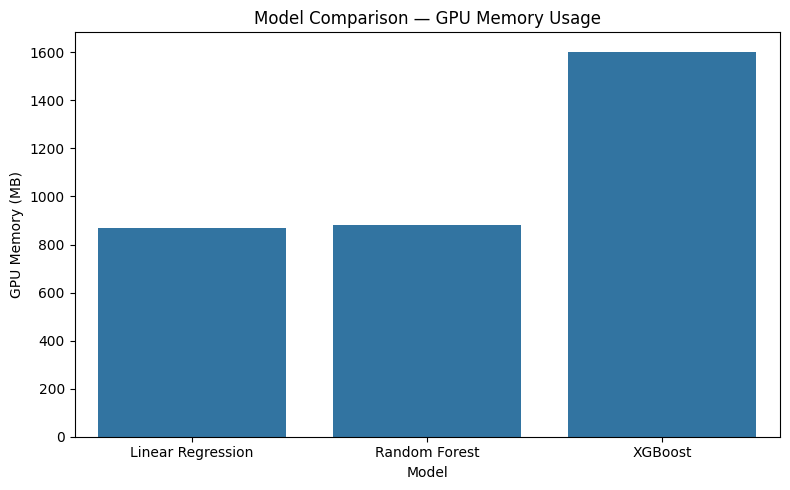

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="GPU Memory Reading (MB)"
)

plt.title("Model Comparison — GPU Memory Usage")
plt.xlabel("Model")
plt.ylabel("GPU Memory (MB)")

plt.tight_layout()
plt.show()

In [ ]:
# Compare feature rankings from Random Forest and XGBoost

importance_comparison = rf_feature_importance.merge(
    xgb_feature_importance,
    on="Feature",
    how="outer",
    suffixes=("_RF", "_XGBoost")
)

importance_comparison

,Feature,Importance_RF,Importance_XGBoost
0,bp_rp,0.065456,62.429913
1,bp_rp_sq,0.115246,48.962517
2,dec_cos,0.145933,43.152706
3,dec_sin,0.081294,35.184696
4,mag_color_interaction,0.117835,27.431536
5,phot_g_mean_mag,0.029558,52.840569
6,phot_g_mean_mag_sq,0.197689,0.000000
7,ra_cos,0.123814,33.117184
8,ra_sin,0.123174,40.412834


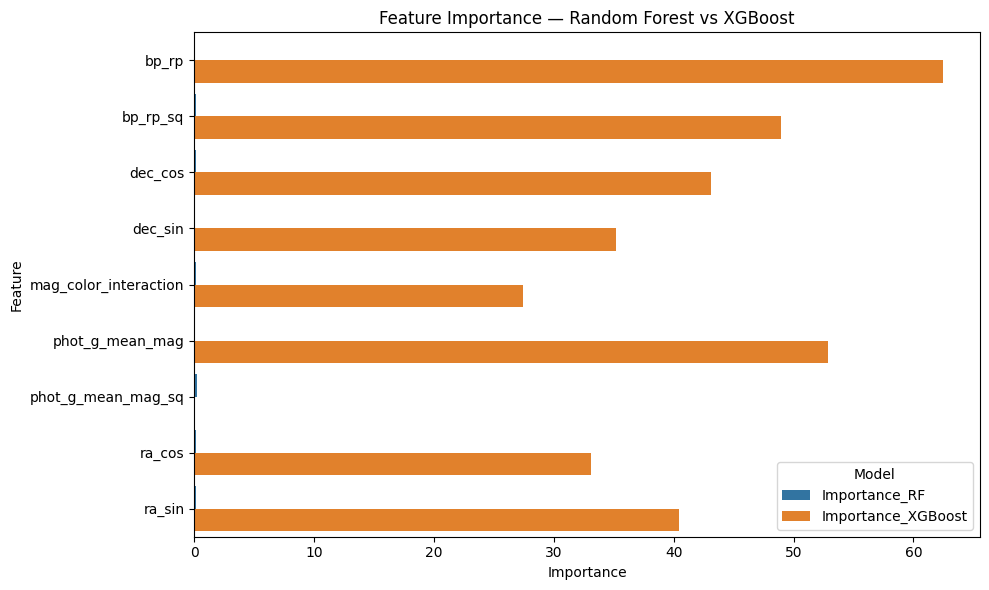

In [ ]:
importance_plot = importance_comparison.melt(
    id_vars="Feature",
    value_vars=["Importance_RF", "Importance_XGBoost"],
    var_name="Model",
    value_name="Importance"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_plot,
    x="Importance",
    y="Feature",
    hue="Model"
)

plt.title("Feature Importance — Random Forest vs XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

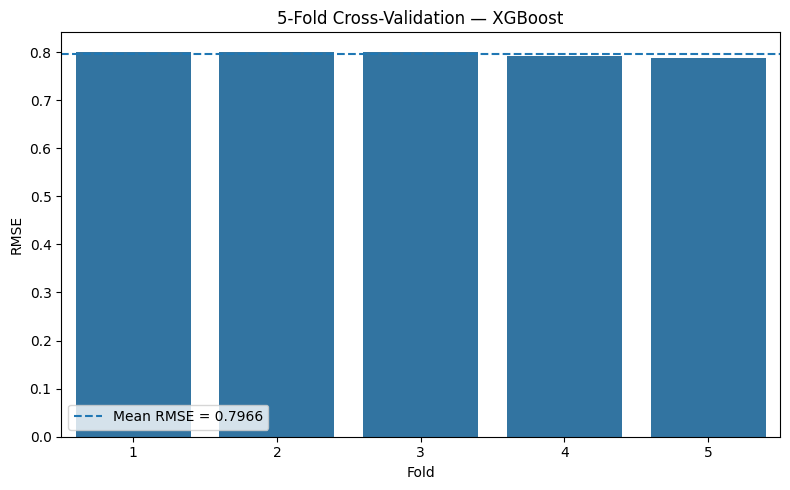

In [ ]:
cv_results = pd.DataFrame({
    "Fold": range(1, len(fold_rmses) + 1),
    "RMSE": fold_rmses
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=cv_results,
    x="Fold",
    y="RMSE"
)

plt.axhline(
    cv_mean,
    linestyle="--",
    label=f"Mean RMSE = {cv_mean:.4f}"
)

plt.title(f"5-Fold Cross-Validation — {best_model_name}")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.legend()

plt.tight_layout()
plt.show()

##18. Conclusions

In this project, three machine learning models were tested to predict Gaia stellar parallax using observable features such as brightness, colour, and sky position.

The results showed that **XGBoost performed the best overall**. The original XGBoost model achieved an RMSE of **0.8003** and an R² of **0.1927**. After hyperparameter tuning, the RMSE slightly improved to **0.7991** and R² increased to **0.1952**. Random Forest achieved a similar performance, while Linear Regression performed worse. These results show that the models were able to learn useful patterns from the selected features, but the features were still not sufficient to explain most of the variation in parallax.

The relatively low R² is reasonable considering the nature of Gaia data. Parallax is a geometric measurement, while most of the selected features describe observable properties such as brightness and colour. In addition, Gaia measurements become less precise for fainter stars, which makes accurate parallax prediction more difficult.

The feature importance results showed that the two tree-based models learned different patterns. XGBoost relied more on colour and brightness, while Random Forest gave more importance to engineered features and sky-position features. This shows that different machine learning models can identify different patterns from the same dataset.

Five-fold cross-validation of XGBoost produced a mean RMSE of **0.7966 ± 0.0052**, showing that the model's performance was relatively consistent across different data splits.

K-Means was also used as an exploratory method to examine whether stars with similar brightness and colour formed meaningful groups. The clusters showed some structure when compared with the Color–Magnitude Diagram, but the groups were not completely separated. Therefore, K-Means was useful for exploring the dataset rather than for predicting parallax.

Overall, the project shows that machine learning can identify useful patterns in a large Gaia dataset. However, predicting parallax using a limited set of observable features remains challenging. The small improvement after hyperparameter tuning also suggests that improving the model alone may have limited impact, and that **additional Gaia astrometric and quality-related features would likely be more important for improving future predictions**.





### Research Question 1 — Can machine learning predict a star's parallax from observable properties?

Yes, the models learned a relationship between the selected features and parallax.

**XGBoost performed best**, with an RMSE of **0.8003** and an R² of **0.1927**. This shows that the model has some predictive ability, but the selected features explain only a limited part of the variation in parallax.

Gaia measurements also become less precise for fainter stars, which can make parallax prediction more difficult.

### Research Question 2 — Which observable features are most strongly associated with parallax?

The important features were different between the two models.

For **XGBoost**, the highest-ranked features were `bp_rp`, `phot_g_mean_mag`, and `bp_rp_sq`.

For **Random Forest**, the highest-ranked features were `phot_g_mean_mag_sq`, `dec_cos`, and `ra_cos`.

This shows that the two models learned different patterns from the same features.

### Did K-Means Recover Meaningful Structure?

K-Means was used to explore whether **brightness and colour** could separate stars into groups.

The clusters were visualized on the Color–Magnitude Diagram. The groups showed some structure, but they were not completely separated. Therefore, K-Means was treated as an **exploratory analysis** and was not used in the regression models.




##19. Future Work

In future work, we could:
1. Test more hyperparameter combinations for Random Forest and XGBoost.
2. Test the models on another Gaia sample to check whether the results remain similar.
3. Try additional Gaia features and check whether they improve the prediction without causing data leakage.
4. Improve the K-Means analysis by testing different values of k.